# 020 · Configurar SARIMA desde el código — `tdb`

En esta libreta vamos a **ajustar SARIMA a la temperatura de bulbo seco
(`tdb`) del ClimaLab** y a aprender cómo elegir e iterar sus siete
parámetros `(p, d, q)(P, D, Q, s)`.

**Sin widgets.** Cada iteración es una celda concreta que editas y vuelves
a ejecutar. La idea es ver *en código* qué pasa al mover cada perilla, y
aprender a leer los diagnósticos (residuos, ACF/PACF de residuos,
Ljung-Box, AIC/BIC, RMSE) para decidir el siguiente cambio.

**Constantes fijas** — para que solo varíen los parámetros SARIMA:

| Pieza | Valor |
|---|---|
| Serie | `tdb` resampleada a **1 hora** |
| Entrenamiento | `2024-03-15 00:00 → 2024-04-11 23:00` (672 obs = 4 semanas) |
| Holdout | `2024-04-12 00:00 → 2024-04-12 23:00` (24 obs = 24 h) |
| Estacionalidad | `s = 24` |
| Horizonte de pronóstico | `h = 24` |
| Métrica principal | RMSE en el holdout |

**El plan.**

1. Cargar y mirar la ventana fija.
2. Recordar qué controla cada parámetro SARIMA.
3. **Deducir** los parámetros iniciales mirando la serie (ADF/KPSS para
   `(d, D)`, ACF/PACF para `(p, q, P, Q)`).
4. Ajustar  modelo 1 **M1**, leer su `summary` y sus diagnósticos.
5. Aprender el **recetario de iteración**.
6. Iterar a **M2** y **M3**, justificando cada cambio.
7. Compararlos en una tabla y **decidir** uno.

### ¿Por qué cada paquete?

Vamos a cargar más imports que de costumbre porque SARIMA toca varias
capas a la vez (datos, modelo, diagnóstico estadístico, gráficas). Vale
la pena nombrar **qué hace cada uno** antes de tenerlos todos juntos:

| Import | Para qué lo necesitamos |
|---|---|
| **`SARIMAX`** (de `statsmodels.tsa.statespace`) | el modelo en sí. Es la implementación más completa de SARIMA en Python — soporta `(p, d, q)(P, D, Q, s)`, da intervalos de confianza y residuos, y la pondremos a hacer `forecast(24)`. |
| **`acf`** (autocorrelation function) | calcula la correlación entre la serie y sus rezagos. Sus picos sugieren `q` (lags pequeños) y `Q` (lags `s, 2s`). |
| **`pacf`** (partial autocorrelation function) | igual que `acf` pero "quitando" la influencia de los rezagos intermedios. Sus picos sugieren `p` y `P`. ACF y PACF se leen **juntas**. |
| **`adfuller`** (Augmented Dickey-Fuller) | prueba de estacionariedad con $H_0$ = "hay raíz unitaria". Si $p < 0.05$ → estacionaria. La usamos sobre `y`, `Δy`, `Δ₂₄y` para decidir `(d, D)`. |
| **`kpss`** (Kwiatkowski-Phillips-Schmidt-Shin) | la prueba *complementaria* de ADF: $H_0$ = "estacionaria". Si $p > 0.05$ → estacionaria. Usamos las dos a la vez porque sus hipótesis nulas son **opuestas** y juntas dan un veredicto sólido. |
| **`acorr_ljungbox`** | la prueba de **Ljung-Box** sobre los residuos del fit. $H_0$ = "los residuos hasta el lag `L` son ruido blanco". Es nuestro **semáforo** de "ya no queda estructura por modelar". |
| **`scipy.stats`** | de aquí solo usamos `stats.probplot` para el **QQ-plot** del diagnóstico (residuos estandarizados vs Normal). |

In [ ]:
import marimo as mo
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from scipy.signal import periodogram

import warnings
warnings.filterwarnings("ignore")

## 1 · Cargar la serie y fijar la ventana

Una sola lectura del parquet, un solo `resample` horario, un solo recorte
con fechas codificadas. A partir de aquí `train` y `test` no cambian.

In [ ]:
f = "data/ClimaLab_2023-05-31_2025-06-20.parquet"
tdb_h = (
    pd.read_parquet(f, columns=["tdb"])["tdb"]
    .resample("h").mean().dropna()
)

# Tres fechas que definen dos intervalos contiguos:
#   train = [f1, f2)   ← 4 semanas
#   test  = [f2, f3)   ← 24 h
f1 = pd.Timestamp("2024-03-15 00:00")
f2 = f1 + pd.Timedelta(weeks=4)
f3 = f2 + pd.Timedelta(hours=24)

train = tdb_h[(tdb_h.index >= f1) & (tdb_h.index < f2)].asfreq("h")
test  = tdb_h[(tdb_h.index >= f2) & (tdb_h.index < f3)].asfreq("h")

print(f"train: {len(train)} obs · {train.index.min()} → {train.index.max()}")
print(f"  media={train.mean():.2f} °C · std={train.std():.2f} °C "
      f"· min={train.min():.2f} · max={train.max():.2f}")
print(f"test : {len(test)} obs · {test.index.min()} → {test.index.max()}")
print(f"  media={test.mean():.2f} °C · std={test.std():.2f} °C")

train: 672 obs · 2024-03-15 00:00:00 → 2024-04-11 23:00:00
  media=27.28 °C · std=4.83 °C · min=16.66 · max=36.11
test : 24 obs · 2024-04-12 00:00:00 → 2024-04-12 23:00:00
  media=27.13 °C · std=4.52 °C


In [ ]:
ventana = pd.concat([
    train.to_frame("tdb").assign(split="train"),
    test.to_frame("tdb").assign(split="holdout (24 h)"),
])
fig_ventana = px.line(
    ventana, y="tdb", color="split",
    title="tdb — ventana de trabajo fija (train + holdout 24 h)",
    labels={"tdb": "tdb (°C)", "date": "fecha"},
)
fig_ventana,ventana

## 2 · Qué controla cada parámetro de SARIMA

Un SARIMA tiene la forma `(p, d, q)(P, D, Q, s)`. Siete números. La
primera tripleta opera **paso a paso**; la segunda opera **en saltos de
`s`** (un día = 24 h, en nuestro caso).

| Símbolo | Qué controla | "Imagen" en `tdb` horario |
|---|---|---|
| `p` | AR de corto plazo — usa $y_{t-1}, \dots, y_{t-p}$ | la temperatura de hace 1–2 h predice la actual |
| `d` | nº de diferencias regulares — quita **tendencia** (la media que sube o baja a largo plazo sin volver: calentamiento, deriva del sensor, cambio de nivel permanente). **No** se usa para ciclos que se repiten. | rara en `tdb`; arrancamos con `d = 0` |
| `q` | MA de corto plazo — usa errores recientes | el error de hace 1 h arrastra |
| `P` | AR estacional — usa $y_{t-s}, y_{t-2s}, \dots$ | "ayer a esta misma hora" |
| `D` | diferencia estacional — calcula $y_t - y_{t-s}$ | trabaja con la diferencia respecto a *ayer* |
| `Q` | MA estacional — usa errores en lags `s, 2s, …` | la sorpresa de ayer a esta hora arrastra |
| `s` | longitud del ciclo | `s = 24` para datos horarios con ciclo diario |

> **Regla práctica.** Mantén `d + D ≤ 2`. Diferenciar de más amplifica el
> ruido. Para series con ciclo diario fuerte y sin tendencia anual marcada,
> `d = 0, D = 1` suele ser el punto de partida correcto.

Los siete parámetros se eligen mirando la serie (siguiente sección) y se
afinan mirando los **residuos** de un fit inicial.

## 3 · Deducir los parámetros iniciales mirando la serie

Vamos a ir por capas, de la mirada más cualitativa a la más cuantitativa:

1. **Perfil diario (boxplot)** → confirma visualmente que hay un ciclo
   de 24 h.
2. **ACF sobre la serie cruda** → debería mostrar picos repetidos en
   lags 24, 48, 72…
3. **PACF sobre la serie cruda** → corrobora con un pico aislado en
   lag 24.
4. **Periodograma (FFT)** → identifica el periodo dominante de forma
   cuantitativa, sin saberlo de antemano.
5. **ADF y KPSS** sobre la serie y sus diferencias → decide `(d, D)`.
6. **ACF y PACF** sobre la serie ya diferenciada → propone
   `(p, q, P, Q)`.

Las cuatro primeras pruebas atacan la misma pregunta — *¿cuál es `s`?* —
desde cuatro ángulos distintos. Si las cuatro coinciden, el valor de
`s` queda fuera de duda.

### 3.1 · Perfil diario — ¿existe el ciclo de 24 h?

Si para cada hora del día (0–23) las temperaturas se concentran en un
rango distinto, hay un ciclo de 24 h y `s = 24` es la elección correcta.

In [ ]:
_hours = train.index.hour
_fig = go.Figure()
for _h in range(24):
    _v = train[_hours == _h]
    _fig.add_trace(go.Box(
        y=_v, name=f"{_h:02d}", boxpoints=False,
        marker_color="#2b6cb0", line=dict(width=1), showlegend=False,
    ))
_fig.update_layout(
    title="Perfil diario en el train — distribución de tdb por hora del día",
    xaxis_title="hora del día", yaxis_title="tdb (°C)",
    height=320, margin=dict(l=40, r=20, t=50, b=40),
    template="plotly_white",
)
_fig

<marimo-plotly data-figure='{"data":[{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"00","showlegend":false,"y":{"dtype":"f8","bdata":"ivo3Qhk9N0Cg0wY6beA2QL9Y8oslnzdAq6qqqqq6N0ALkHvNhYQ6QD81XrpJPDlAN4lBYOVgOUBLxdmHzzA4QKxjggfzhDhAgNxrLiRtN0AcoYzelpU0QPS2rNUxATVAIWlKxdknNUCeqH8jlEE3QDdCGb0tyzdAjlBGb8vKN0ApXI/C9Sg4QK3VMcGDWThAZmZmZmbmN0DDrgC51yw3QIxs5/upUThAdUzwYJ64NkCTXyz5xUI3QNyyVscEfzhAQhm9LWs1OkCXbhKDwDo4QEcoo7dl7ThAj8L1KFzPN0A="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"01","showlegend":false,"y":{"dtype":"f8","bdata":"YCz5xZIvNkBrdUzwYC42QOwKkHvNpTdA7cNn2BUAOEAL16NwPWo6QEfhehSuBzlAbaDTBjr9OEDJveZC0gQ3QElTKs4+zDdAAiuHFtnONkBRRm/LWi00QEFg5dAiSzRA2ofPsCuQNED5DLsC5G42QDeJQWDlADZA2/l+arxUN0DkXnMhaQo4QKxjggfz1DdA5BdLfrHUNkC3rNUxwdM2QHzNhaQpRTdA/WLJL5YsNkAavS1rdRw3QPNE/RuhvDdADElTKs4+OUB/arx0k7g3QC2yne+nJjhAA5020GmTN0A="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"02","showlegend":false,"y":{"dtype":"f8","bdata":"0pSKsw+fNUAVZx8+w642QI5QRm/LejdA+sWSXywpN0D24TPsClA5QKfGSzeJETlAQO41F5I2OEDsUbgehds2QLkehetRODdAQacNdNpwNUCDwMqhRTYyQMxaHRM8+DNAtqzVMcGTM0BgLPnFkg82QA4tsp3vNzVAWx0TPJjnNUBD0pSKs+82QAaBlUOLPDdAAXKvuZBENkBjggfzRH02QMxaHRM8KDdA5BdLfrHUNEAwlvxiyQ82QNqHz7ArUDdAFtnO91PTOEC/nxov3UQ3QBeSplSc7TVAlYqzD58BN0A="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"03","showlegend":false,"y":{"dtype":"f8","bdata":"Zx8+w65ANUAH80T9G2E2QCGwcmiRjTdA0wY6baBzNUDyiyW/WLI3QDBP1L8RijhAxdmHz7DLN0AsQO41F1I2QElTKs4+nDZAUrgehethNEByr7mQNMUxQI8JHswThTNAxwQP5ol6MkCmVJx9+Iw0QG3n+6nxQjRAKaO3Za2+NUBsdUzwYP41QNCwK0DuRTdAzj58hl2RNUDpbVmrY+I1QJ7vp8ZL9zZACWX0tqzVM0CuR+F6FB41QCOU0duypjZAgZVDi2z3N0D0/dR46UY2QEIZvS1rdTVABci95kLCNkA="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"04","showlegend":false,"y":{"dtype":"f8","bdata":"bHVM8GCuNEDhehSuR/E1QKGM3pa1GjZAIWlKxdk3NEA9Uf9GKIM3QFJx9uEzHDdAVscED+b5NkB/arx0k4g1QGGeqH8jBDZA8GCeqH+DM0CHz7ArQK4xQLsC5F5zATNAhxbZzvdzMkBfcyFpSpUzQHVM8GCeaDNAjGzn+6kxNUANuwLkXlM1QGJXgNxrHjZAZx8+w66wNUDv7u7u7t41QIXrUbgeNTZAf2q8dJNINECiRbbz/cQ0QH74DLsCBDZA4XoUrkeRN0DzRP0bocw1QB4TPJgnujRAi2zn+6lRNkA="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"05","showlegend":false,"y":{"dtype":"f8","bdata":"HswT9W9kNECBlUOLbJc0QJa1OiZ4UDVAKaO3Za1uNEA9Uf9GKPM2QIZdAXKvSTZAjGzn+6lRNkAeEzyYJ2o1QE3wYJ6orzVAhl0Bcq9pM0AxCKwcWnQxQC35xZJfXDJABFYOLbJtMUBVVVVVVeUyQH0/NV66GTNAn6h/I5SxNECK+jdCGV00QC2yne+nBjVAoNMGOm0wNUA0peLsw/c0QLMPn2FXMDVAk18s+cXyM0C1OiZ4MA80QEPSlIqzPzVAnTbQaQN9NkCWtTomeKA1QEw3iUFgJTRAeekmMQjMNUA="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"06","showlegend":false,"y":{"dtype":"f8","bdata":"F5KmVJzNM0AQn2FXgAw0QFFGb8taLTRA7nw/NV76NEB1TPBgnug1QGu8dJMYNDZAppvEILByNUD5DLsC5C41QORecyFpKjVAH4XrUbjuMkBpke18P8UwQEZvy1odwzFA5on6N0KpMEDVeOkmMfgxQE8b6LSBjjJASZpScfZRNECOUEZvyxo0QGZmZmZmBjVAfrHkF0vuNECW/GLJL/Y0QEX9G6GMzjRA9Las1TGxM0DW6pjgwYwzQGAs+cWSzzRA0SLb+X5KNkA1XrpJDNI0QMXZh8+wuzNAZx8+w67gNEA="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"07","showlegend":false,"y":{"dtype":"f8","bdata":"5kLSlIoTNUDRItv5fqo0QMRn2BUg1zRAakrF2Ye/NUDQaQOdNhA2QHKvuZA01TZA/WLJL5YcNkCLsw+fYSc2QM3MzMzMTDZAd3d3d3e3NECujgkezEMyQNUxwYN5QjJAS8XZh8+wMkA6baDTBlozQNCwK0Du1TNAlUOLbOdLNUB3d3d3dyc1QBbZzvdT0zZA20CnDXRKNkBn2BUg95o2QLsC5F5zwTZAke18PzX+NUDrmODBPME1QIIH80T96zZAUI2XbhLzN0CbUnH24cM2QCuHFtnO9zVA3WsuJE35N0A="},"type":"box"},{"boxpoints":false,"line":{"width":1},"marker":{"color":"#2b6cb0"},"name":"08","showlegend":false,"y":{"dtype":"f8","bdata":"r7mQNKXSOUBBpw102nA6QGwuJE2p2DlAhxbZzvezOkCPwvUoXI85QM6FpCkVhzpApeLsw2e4OkAhaUrF2Qc7QJE0peLskzpAgZVDi2xXOUBwhDJ6W9Y3QHKvuZA0hTdA2c73U+N1OEA1XrpJDFI3QAll9LasZThAZfS2rNXhOEAiIiIiIhI6QI2XbhKDsDpASlMqzj6cOUDMWh0TPJg6QMZLN4lBwDhAVscED+YJOkCZ4ME8UT86QNKUirMPrzpAx73mQtJkO0BfcyFpShU7QOaJ+jdC6TlAERERERHROkA="}

**Lectura.** Las cajas se separan claramente: las horas centradas en el
mediodía solar están muy por encima de las nocturnas. El ciclo diario es
real y dominante → **`s = 24`**.

### 3.2 · ACF de la serie cruda — ¿se repite el patrón?

Una señal con periodo `s` produce una **ACF también periódica con el
mismo periodo**. Si la temperatura a las 14:00 de hoy se parece a la
de las 14:00 de ayer, esperamos correlación alta en lag 24, y de nuevo
en 48, 72…

Las líneas naranjas punteadas marcan esos lags candidatos.

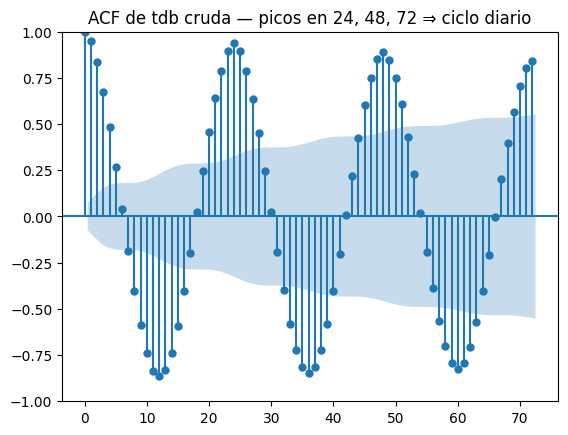

In [ ]:
fig_acf_crudo = plot_acf(
    train.values, lags=72,
    title="ACF de tdb cruda — picos en 24, 48, 72 ⇒ ciclo diario",
)
fig_acf_crudo

**Lectura.** Picos grandes y positivos en **lags 24, 48, 72** (líneas
naranjas) — la firma inequívoca de un ciclo de 24 h. Entre medias,
aparecen mínimos negativos en lags ≈12, 36, 60 — porque la temperatura
a las 02:00 está *anti*-correlacionada con la de las 14:00. El
decaimiento muy lento de los picos confirma que es **estacionalidad**,
no memoria AR corta.

---

### 3.3 · PACF de la serie cruda — apoyo

La **PACF** mide la correlación *parcial*, quitando el efecto de los
lags intermedios. Para un ciclo puro suele aparecer un **pico aislado
en lag `s`** sin necesidad de picos en 2s, 3s… (eso ya queda
"explicado" por el primero).

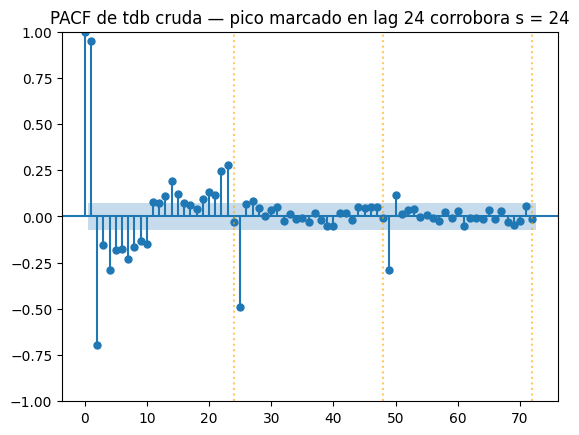

In [ ]:
fig_pacf_crudo = plot_pacf(
    train.values, lags=72, method="ywm",
    title="PACF de tdb cruda — pico marcado en lag 24 corrobora s = 24",
)
for _k in (24, 48, 72):
    fig_pacf_crudo.axes[0].axvline(_k, color="orange", linestyle=":", alpha=0.6)
fig_pacf_crudo

**Lectura.** Picos fuertes en los primeros lags (1–2, dinámica de
corto plazo) y un pico extra **alrededor del lag 24**. Los lags 48 y 72
no necesitan ser grandes — la PACF ya descontó esa información.
Veredicto: el ciclo de 24 h también aparece aquí.

---

### 3.4 · Periodograma (FFT) — confirmación cuantitativa

Hasta aquí hemos visto el ciclo *cualitativamente*. La transformada de
Fourier discreta lo descubre **sin que le digamos el periodo de
antemano**: descompone la serie en sinusoides y nos dice cuánta
energía hay en cada frecuencia. Un ciclo de 24 h aparecerá como un
pico nítido en la frecuencia $f = 1/24 \approx 0.0417$ ciclos/hora.

Mostramos la potencia espectral **vs. periodo** (más intuitivo que
frecuencia): el eje x está en horas, y el pico marca el periodo
dominante.

In [ ]:
# fs = 1 muestra/hora → frecuencias en ciclos/hora, periodos en horas
_freqs, _potencia = periodogram(train.values, fs=1.0)

# saltamos la componente DC (f = 0) y convertimos a periodo
_periodos_h = 1 / _freqs[1:]
_potencia_no_dc = _potencia[1:]
_periodo_dominante = _periodos_h[_potencia_no_dc.argmax()]

fig_fft = px.line(
    x=_periodos_h, y=_potencia_no_dc, log_x=False, log_y=False,
    labels={"x": "periodo (horas)",
            "y": "potencia espectral"},
    title=(
        f"Periodograma — pico dominante en {_periodo_dominante:.1f} h"
        " ⇒ confirma s = 24"
    ),
)
fig_fft.add_vline(x=24, line_dash="dot", line_color="orange",
                  annotation_text="24 h")

print(f"Periodo dominante detectado por FFT: {_periodo_dominante:.2f} h")
fig_fft

Periodo dominante detectado por FFT: 24.00 h


<marimo-plotly data-figure='{"data":[{"hovertemplate":"periodo (horas)=%{x}<br>potencia espectral=%{y}<extra></extra>","legendgroup":"","line":{"color":"#636efa","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"","orientation":"v","showlegend":false,"x":{"dtype":"f8","bdata":"AAAAAAAAhUAAAAAAAAB1QAAAAAAAAGxAAAAAAAAAZUDNzMzMzMxgQAAAAAAAAFxAAAAAAAAAWEAAAAAAAABVQKuqqqqqqlJAzczMzMzMUECNLrroootOQAAAAAAAAExAip3YiZ3YSUAAAAAAAABIQGdmZmZmZkZAAAAAAAAARUDEw8PDw8NDQKuqqqqqqkJA8xrKayivQUDNzMzMzMxAQAAAAAAAAEBAjS666KKLPkDUm970pjc9QAAAAAAAADxA4XoUrkfhOkCKndiJndg5QDqO4ziO4zhAAAAAAAAAOEA1wnJPIyw3QGdmZmZmZjZArrXWWmutNUAAAAAAAAA1QF100UUXXTRAxMPDw8PDM0A0MzMzMzMzQKuqqqqqqjJAmCKfdYMpMkDzGsprKK8xQLITO7ETOzFAzczMzMzMMEBkcD4G52MwQAAAAAAAADBA0Rf0BX1BL0CNLrrooosuQN7d3d3d3S1A1Jve9KY3LUByBTG5gpgsQAAAAAAAACxA3LZt27ZtK0DhehSuR+EqQFtaWlpaWipAip3YiZ3YKUB+DqkJxlspQDqO4ziO4yhAcFj7hrVvKEAAAAAAAAAoQER5DeU1lCdANcJyTyMsJ0BCw0ndl8cmQGdmZmZmZiZAbd6nuGQIJkCutdZaa60lQFVVVVVVVSVAAAAAAAAAJUDVSq3USq0kQF100UUXXSRAXPjVmEgPJEDEw8PDw8MjQDi96U1veiNANDMzMzMzI0C/XerJ+O0iQKuqqqqqqiJAlCZNmjRpIkCYIp91gykiQOxRuB6F6yFA8xrKayivIUB10UUXXXQhQLITO7ETOyFAB6LSkT0DIUDNzMzMzMwgQHwJ7SW0lyBAZHA+BudjIEDo1x5yWTEgQAAAAAAAACBAoJ+fn5+fH0DRF/QFfUEfQEhY7mmE5R5AjS666KKLHkDjGc94xjMeQN7d3d3d3R1AntiJndiJHUDUm970pjcdQOicc8455xxAcgUxuYKYHEC3xKnfc0scQAAAAAAAABxAnOVJZBq2G0Dctm3btm0bQCebbLLJJhtA4XoUrkfhGkAavhEFJp0aQFtaWlpaWhpA1B3st9oYGkCKndiJndgZQJqZmZmZmRlAfg6pCcZbGUD8hVhRGh8ZQDqO4ziO4xhAk4q51RmpGEBwWPuGtW8YQHaDKfJZNxhAAAAAAAAAGEAOmnzZoMkXQER5DeU1lBdAdknlw7hfF0A1wnJPIywXQJdv+ZZv+RZAQsNJ3ZfHFkCXlpaWlpYWQGdmZmZmZhZAfa2eHQI3FkBt3qe4ZAgWQNuVqF2J2hVArrXWWmutFUAbL90kBoEVQFVVVVVVVRVAS6VSqVQqFUAAAAAAAAAVQDZlTVlT1hRA1Uqt1EqtFECau+Cv4oQUQF100UUXXRRAX0N5DeU1FEBc+NWYSA8UQJQ+6ZM+6RNAxMPDw8PDE0BLGJsF1Z4TQDi96U1vehNAAt2Yp49WE0A0MzMzMzMTQE2uICZXEBNAv13qyfjtEkAHRIZ7FcwSQKuqqqqqqhJAXpso2bWJEkCUJk2aNGkSQJIkSZIkSRJAmCKfdYMpEkDUMZcITwoSQOxRuB6F6xFAjzRHmiPNEUDzGsprKK8RQJKRkZGRkRFAddFFF110EUBYkXgViVcRQLITO7ETOxFAOkG4G/seEUAHotKRPQMRQKkJxlvZ5xBAzczMzMzMEEALWchCFrIQQHwJ7SW0lxBAaxRx6KR9EEBkcD4G52MQQEuQpwR5ShBA6NceclkxEECxq/DlhhgQQAAAAAAAABBAgpoK0YbPD0Cgn5+fn58PQAX3EdxHcA9A0Rf0BX1BD0DBNqerPBMPQEhY7mmE5Q5Auh6F61G4DkCNLrrooosOQFcEDSd1Xw5A4xnPeMYzDkA1Oci8lAgOQN7d3d3d3Q1AXoa90p+zDUCe2Imd2IkNQOh9ikuGYA1A1Jve9KY3DUD10DG8OA8NQOicc8455wxAvxyRYqi/DEByBTG5gpgMQBzHcRzHcQxAt8Sp33NLDEC8jClfhyUMQAAAAAAAAAxA5VTAL9zaC0Cc5UlkGrYLQBy5kRu5kQtA3LZt27ZtC0BCdmExEkoLQCebbLLJJgtAh7Ha+tsDC0DhehSuR+EKQHqgcnYLvwpAGr4RBSadCkBiuacRlnsKQFtaWlpaWgpAOhqXo3E5CkDUHey32hgKQKBR4meU+AlAip3YiZ3YCUAyJ+D59LgJQJqZmZmZmQlAjmkTUIp6CUB+DqkJxlsJQKon47dLPQlA/IVYURofCUAOE5DRMAEJQDqO4ziO4whAxxhjjDHGCECTirnVGakIQMSIESNGjAhAcFj7hrVvCEAYZ1MYZ1MIQHaDKfJZNwhA3cCoM40bCEAAAAAAAAAIQOUXS36x5AdADpp82aDJB0AdLUhAza4HQER5DeU1lAdAGaLD/dl5B0B2SeXDuF8HQEYXXXTRRQdANcJyTyMsB0BtlbiYrRIHQJdv+ZZv+QZAjzcnlGjgBkBCw0ndl8cGQF8tbsL8rgZAl5aWlpaWBkBET6qvZH4GQGdmZmZmZgZAFptOFptOBkB9rZ4dAjcGQKQMPN2aHwZAbd6nuGQIBkAWX/EVX/EFQNuVqF2J2gVAP1zR+uLDBUCutdZaa60FQDV1fu0hlwVAGy/dJAaBBUBFdEp1F2sFQFVVVVVVVQVAgyu5Pb8/BUBLpVKpVCoFQBUVFRUVFQVAAAAAAAAABUAV6xTrFOsEQDZlTVlT1gRAHEyRz7rBBEDVSq3USq0EQDCQSfECmQRAmrvgr+KEBEAH/7ac6XAEQF100UUXXQRAMaXtOmtJBEBfQ3kN5TUEQEIRilCEIgRAXPjVmEgPBEAWTat8MfwDQJQ+6ZM+6QNAXHH4d2/WA0DEw8PDw8MDQBQ7sRM7sQNASxibBdWeA0CNE8k4kYwDQDi96U1vegNAswMM525oA0AC3Zinj1YDQEUTTTTRRANANDMzMzMzA0DKm51LtSEDQE2uICZXEANA2h2NbBj/AkC/XerJ+O0CQNAtcer33AJAB0SGexXMAkC8ErUrUbsCQKuqqqqqqgJAQLgwqSGaAkBemyjZtYkCQBOZhu1meQJAlCZNmjRpAkDkTIiUHlkCQJIkSZIkSQJAAWmhSkY5AkCYIp91gykCQG9nSMzbGQJA1DGXCE8KAkA0THXl3PoBQOxRuB6F6wFAd8QdcUfcAUCPNEeaI80BQLx+tlgZvgFA8xrKayivAUC+frmTUKABQJKRkZGRkQFA3jIxJ+uCAUB10UUXXXQBQOITSCXnZQFAWJF4FYlXAUDBmtysQkkBQLITO7ETOwFAyloZ6fssAUA6Qbgb+x4BQBEREREREQFAB6LSkT0DAUBefF5ngPUAQKkJxlvZ5wBAD9PHOUjaAEDNzMzMzMwAQKiu5eBmvwBAC1nIQhayAECKRs2/2qQAQHwJ7SW0lwBAd9W9Q6KKAEBrFHHopH0AQAwH0eO7cABAZHA+BudjAEBCTK4gJlcAQEuQpwR5SgBAfvdAhN89AEDo1x5yWTEAQE8CcaHmJABAsavw5YYYAEBKYN4TOgwAQAAAAAAAAABA"},"xaxis":"x","y":{"dtype":"f8","bdata":"loUh3HRGaEBKivRAMDdlQKhBzmM+rGNA2rAgMYFAEECXCb7vxaVDQL5yRgXbjCRANkLZwKLoO0ABLo

**Lectura.** El pico más alto del periodograma está exactamente en
**24 horas** — la FFT *descubre* el ciclo sin que le hayamos dado pista
alguna. Hay picos secundarios en 12 h y 8 h (armónicos del ciclo
diario, naturales en una señal no perfectamente sinusoidal).

---

**Veredicto combinado.** Las cuatro pruebas (boxplot, ACF, PACF, FFT)
coinciden: el ciclo dominante es de **24 h**. Fijamos $s = 24$ con
total confianza y pasamos a decidir cuántas diferencias necesitamos.

### 3.5 · ADF y KPSS — ¿qué `(d, D)` deja la serie estacionaria?

SARIMA exige una serie **estacionaria** *después* de aplicar `d`
diferencias regulares y `D` diferencias estacionales. Probamos cuatro
transformaciones y, en cada una, corremos dos pruebas con hipótesis
nulas **opuestas**:

| Prueba | $H_0$ | Conclusión cuando **rechazamos** $H_0$ |
|---|---|---|
| **ADF** | "hay raíz unitaria" | la serie es estacionaria ✓ |
| **KPSS** | "la serie es estacionaria" | la serie **no** es estacionaria ✗ |

Buscamos: **ADF p < 0.05 y KPSS p > 0.05 simultáneamente**, con la menor
cantidad posible de diferencias.

In [ ]:
def _stat_row(name, s, *, d, D):
    x = s.dropna()
    adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
    return {
        "d": d, "D": D, "transformación": name, "n": len(x),
        "ADF stat": round(adf_stat, 3), "ADF p": round(adf_p, 4),
        "ADF": "estacionaria" if adf_p < 0.05 else "NO estac.",
        "KPSS stat": round(kpss_stat, 3), "KPSS p": round(kpss_p, 4),
        "KPSS": "estacionaria" if kpss_p > 0.05 else "NO estac.",
    }

stationarity = pd.DataFrame([
    _stat_row("y",       train,                   d=0, D=0),
    _stat_row("Δy",      train.diff(),            d=1, D=0),
    _stat_row("Δ₂₄ y",   train.diff(24),          d=0, D=1),
    _stat_row("Δ Δ₂₄ y", train.diff().diff(24),   d=1, D=1),
])
stationarity

,d,D,transformación,n,ADF stat,ADF p,ADF,KPSS stat,KPSS p,KPSS
0,0,0,y,672,-2.456,0.1266,NO estac.,0.105,0.1,estacionaria
1,1,0,Δy,671,-18.060,0.0000,estacionaria,0.008,0.1,estacionaria
2,0,1,Δ₂₄ y,648,-7.945,0.0000,estacionaria,0.077,0.1,estacionaria
3,1,1,Δ Δ₂₄ y,647,-12.011,0.0000,estacionaria,0.032,0.1,estacionaria


**Lectura.**

- `y` sin diferenciar: ADF apenas rechaza (p ≈ 0.05) y KPSS la considera
  no estacionaria. El ciclo diario hace que la media local varíe entre
  noche y día.
- **`Δ₂₄ y` (sola diferencia estacional)** ya pasa las dos pruebas: ADF
  bajo, KPSS alto. **Es la elección mínima que estaciona la serie.**
- `Δy` y `Δ Δ₂₄ y` también pasan, pero ya estaríamos **diferenciando de
  más**: cualquier ruido se amplifica al diferenciar.

> Decisión: **`d = 0`, `D = 1`, `s = 24`**.

### 3.6 · ACF y PACF de la serie diferenciada — `(p, q, P, Q)`

Ya decidimos `d = 0, D = 1, s = 24`. **Ahora, sobre la serie ya
estacionaria, leemos la ACF y la PACF para proponer los órdenes que
faltan `(p, q, P, Q)`.** La celda de abajo dibuja esas dos funciones a
mano (con barras) en vez de usar `plot_acf`/`plot_pacf`, solo para tener
control total del estilo; el cálculo es el mismo.

**Por qué sobre `Δ₂₄ y` y no sobre la serie cruda.** SARIMA modela lo que
queda *después* de diferenciar. Por eso primero aplicamos la diferencia
estacional —`Δ₂₄y_t = y_t − y_{t−24}`, cada hora menos la misma hora de
ayer— y recién sobre ese residuo medimos la autocorrelación. (Los primeros
24 valores quedan en `NaN` porque no tienen "ayer"; se descartan.)

**La regla de lectura** — ACF y PACF se leen siempre **juntas**:

| Función | Mide | Sus picos sugieren |
|---|---|---|
| **ACF** (autocorrelación) | correlación bruta con el rezago `k` | **MA**: lags 1, 2, … → **`q`**; lags `s, 2s` → **`Q`** |
| **PACF** (parcial) | correlación con el rezago `k` *descontando* los intermedios | **AR**: lags 1, 2, … → **`p`**; lags `s, 2s` → **`P`** |

Mnemotecnia: **ACF → MA (`q, Q`)**, **PACF → AR (`p, P`)**.

**Por qué la banda ±1.96/√n.** Las líneas grises punteadas marcan la
**banda de significancia del 95% bajo la hipótesis de ruido blanco**. El
argumento: si la serie diferenciada fuera ruido blanco puro, sus
autocorrelaciones muestrales $\hat r_k$ no serían exactamente 0 por azar,
sino que se distribuirían aprox. $\hat r_k \sim \mathcal{N}(0,\, 1/n)$
(resultado de Bartlett). Su desviación estándar es $1/\sqrt{n}$, y el
intervalo del 95% de una normal es $\pm 1.96\,\sigma = \pm 1.96/\sqrt{n}$.
Con $n \approx 648$ sale $\approx \pm 0.077$.

> **Cómo se lee:** una barra **dentro** de la banda gris es
> indistinguible de cero (ruido, no la modelamos); una barra que
> **sobresale** es un pico estadísticamente significativo → ese lag
> aporta estructura y hay que capturarlo con el parámetro correspondiente.
> Es el criterio objetivo que reemplaza el "se ve grande a ojo".

Calculamos hasta el **lag 48 = 2 ciclos diarios** a propósito: para juzgar
lo estacional hace falta ver tanto `s = 24` como `2s = 48` (las líneas
naranjas). Si solo llegáramos a 24 no podríamos distinguir entre "basta
con `Q = 1`" y "hace falta más memoria estacional".

In [ ]:
_diff = train.diff(24).dropna()
_nlags = 48
_ci = 1.96 / np.sqrt(len(_diff))

_acf_vals  = acf(_diff.values, nlags=_nlags, fft=True)
_pacf_vals = pacf(_diff.values, nlags=_nlags, method="ywm")

fig_acf = make_subplots(
    rows=1, cols=2,
    subplot_titles=("ACF de Δ₂₄ y", "PACF de Δ₂₄ y"),
)
for _col, (_v, _nm) in enumerate(
    [(_acf_vals, "ACF"), (_pacf_vals, "PACF")], start=1
):
    fig_acf.add_trace(
        go.Bar(
            x=list(range(len(_v))), y=_v, marker_color="#2b6cb0",
            hovertemplate="lag=%{x}<br>r=%{y:.3f}<extra></extra>",
            showlegend=False,
        ),
        row=1, col=_col,
    )
    fig_acf.add_hline(y=_ci,  line=dict(dash="dash", color="grey"), row=1, col=_col)
    fig_acf.add_hline(y=-_ci, line=dict(dash="dash", color="grey"), row=1, col=_col)
    for _k in (24, 48):
        fig_acf.add_vline(x=_k, line=dict(color="orange", width=1, dash="dot"),
                          row=1, col=_col)

fig_acf.update_layout(
    height=340, template="plotly_white",
    margin=dict(l=40, r=20, t=50, b=40),
)
fig_acf.update_xaxes(title_text="lag (horas)")
fig_acf

<marimo-plotly data-figure='{"data":[{"hovertemplate":"lag=%{x}<br>r=%{y:.3f}<extra></extra>","marker":{"color":"#2b6cb0"},"showlegend":false,"x":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48],"y":{"dtype":"f8","bdata":"AAAAAAAA8D8JO1JDtD7qP0W5oFkxFuU/76Kjmpem4T+nniNrsCTePxapR35ZEds/SjkWwAnY2D8GYyqQqpvVP6wmP4y1v9I/3blpnkRO0T+7xmCmaGfOP+Ca/iBgfco/uPLzkehKyD80enS4LcPEP7t9EOaxucA/TrTQzcY0vT+eEmjr8ly9P4fOBkKEKrg/q8EA4AIlsT+CPaEPUTSmP7AVu6YFx30/B8fbOIq4rL8tvR1W7XHAv4F9VTiEDsy/YUmWH2ox1L/5ztzI5yrMv6fc5+E0OsK/yRW6sjxquL8y/SirqMGwv4cueqhpMLC/lqlkpyYKsL+5qY6AOBymv3u5RB3HIJ6/vu4Aktv6lr8X+fCq08uTv08q9BMk7IS/Y0ewPzjak79EGIN6GlyEvwR3LEjMdW2/ud7OztjKi7/49uQ93H2kv/A/Ysp0Uq+/OKge/EKRsL82wqwS26iyv8tektxB2qy/iI/ddXVah7+noVQ/F+WkP9B6FQshc7A/BodqeW53sz8="},"type":"bar","xaxis":"x","yaxis":"y"},{"hovertemplate":"lag=%{x}<br>r=%{y:.3f}<extra></extra>","marker":{"color":"#2b6cb0"},"showlegend":false,"x":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48],"y":{"dtype":"f8","bdata":"AAAAAAAA8D8KO1JDtD7qP71NxM0ua6W/3ZVmr3DksT8CPz/rDiKYP2BjIzwlvLE/lKHraksZoT8e4jQod4ajv1RycHU0CYI/MotyVRcuqD/uPfXDK9Wgv6ulxHIFwVC/7t0+4CeFmD8MhDddu1qev9XKqYNsj5e/ApJCvEbFkT+NSNGUia2nP8Kbn170gqy/14bmlTB8oL9ebN8KEPl+v/jBTEPptqy/1EsqyuAAwb/IgTtwNw28v/NgO+F7xMO/fhi713ZrxL9XZsRTEErdP8AuBeKrXJW/aR1RsbzNrT83+KSw+m+BPwjvrj8hI4q/h1Zezpw2mT/Sgqv7ACNxv3R5I2hdupC/yj/sqmtmoz8zqWVs56ipv3Ko0vqFZKc/24AiNtELpL8vt100W2aUP/6aYMhw8JG/FBuzwRDYh79ChwK71dWSv42NZAafva6/vKW6lp1zjz/qTTs06TGtvxIIJHSCiqU/CYG4CK8enz9rAyo4m5ukPzy0VchBwr6/5p6B5sYisL8="},"type":"bar","xaxis":"x2","yaxis":"y2"}],"layout":{"template":{"data":{"barpolar":[{"marker":{"line":{"color":"white","width":0.5},"pattern":{"fillmode":"overlay","size":10,"solidity":0.2}},"type":"barpolar"}],"bar":[{"error_x":{"color":"#2a3f5f"},"error_y":{"color":"#2a3f5f"},"marker":{"line":{"color":"white","width":0.5},"pattern":{"fillmode":"overlay","size":10,"solidity":0.2}},"type":"bar"}],"carpet":[{"aaxis":{"endlinecolor":"#2a3f5f","gridcolor":"#C8D4E3","linecolor":"#C8D4E3","minorgridcolor":"#C8D4E3","startlinecolor":"#2a3f5f"},"baxis":{"endlinecolor":"#2a3f5f","gridcolor":"#C8D4E3","linecolor":"#C8D4E3","minorgridcolor":"#C8D4E3","startlinecolor":"#2a3f5f"},"type":"carpet"}],"choropleth":[{"colorbar":{"outlinewidth":0,"ticks":""},"type":"choropleth"}],"contourcarpet":[{"colorbar":{"outlinewidth":0,"ticks":""},"type":"contourcarpet"}],"contour":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"contour"}],"heatmap":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"heatmap"}],"histogram2dcontour":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"histogram2dcontour"}],"histogram2d":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#

**Lectura de los picos.**

- **Lags pequeños (1, 2)** — ACF y PACF tienen un pico en el lag 1 y
  decaen rápido. Eso es señal de **`p = 1`** y/o **`q = 1`**.
- **Lag 24 (línea naranja)** — la ACF tiene un **pico negativo grande**;
  la PACF también muestra estructura ahí. Es la firma típica de
  **`Q = 1`** combinada con la diferencia estacional `D = 1`.
- **Lag 48** — un pico residual mucho menor que el de 24, sugiere que
  con `P = 1` o `Q = 1` ya capturamos casi todo lo estacional.

> **Propuesta de modelo inicial — M1:**
> $$\text{SARIMA}(1, 0, 1)(1, 1, 1)_{24}$$
> Es la receta "todo a 1" en ambas escalas: AR y MA simples en lo
> regular, AR y MA simples en lo estacional, con una diferencia
> estacional. **Es el mejor punto de partida** y desde aquí iteramos.

## 4 · Ajustar **M1** paso a paso — sin helpers

Antes de empaquetar nada en funciones, hacemos **un solo modelo a
mano**, paso a paso, para que se vea cada operación con claridad. Las
funciones de la siguiente sección (§5) serán exactamente esto,
*empacado*.

El modelo es el que dedujimos en §3:
$$\text{SARIMA}(1, 0, 1)(1, 1, 1)_{24}.$$

### 4.1 · Ajustar el modelo

`SARIMAX` toma la serie de entrenamiento y los dos órdenes — el
regular `(p, d, q)` y el estacional `(P, D, Q, s)`. Las opciones
`enforce_*=True` exigen que el modelo final sea estacionario e
invertible (parámetros dentro del círculo unidad).

In [ ]:
res_M1 = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=True,
    enforce_invertibility=True,
).fit(disp=False)

print(res_M1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                tdb   No. Observations:                  672
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood                -533.483
Date:                            Wed, 27 May 2026   AIC                           1076.965
Time:                                    11:49:59   BIC                           1099.334
Sample:                                03-15-2024   HQIC                          1085.643
                                     - 04-11-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8967      0.019     47.925      0.000       0.860       0.933
ma.L1          0.0147      0.040   

**Cómo leer el `summary`.**

- **Bloque "SARIMAX Results"** — tamaño de muestra, log-likelihood,
  AIC, BIC.
- **Tabla de coeficientes** — uno por término del modelo:
  - `ar.L1`, `ma.L1` → coeficientes regulares ($\phi_1$, $\theta_1$).
  - `ar.S.L24`, `ma.S.L24` → coeficientes estacionales ($\Phi_1$, $\Theta_1$).
  - `sigma2` → varianza estimada del ruido $\varepsilon$.
  - Columna `P>|z|` → **p-valor del coeficiente**. Si es < 0.05 el
    término aporta; si es > 0.1 es candidato a quitarlo.
- **Bloque "Ljung-Box (L1) (Q)" y "Jarque-Bera"** — el primero mide
  autocorrelación residual en lag 1 (queremos p alto); el segundo
  mide normalidad de los residuos (informativo, no crítico).

**Lectura del `summary` de M1.**

Los cuatro `coef` son los parámetros que el modelo aprendió del train y
usa para pronosticar. Cada uno multiplica un término de la ecuación:

| en el `summary` | símbolo | qué multiplica | valor | `P>|z|` |
|---|---|---|---|---|
| `ar.L1`    | $\phi_1$   | $w_{t-1}$ (hace 1 h)            | **0.897**  | 0.000 ✅ |
| `ma.L1`    | $\theta_1$ | $\varepsilon_{t-1}$ (error 1 h) | 0.015      | 0.712 ❌ |
| `ar.S.L24` | $\Phi_1$   | $w_{t-24}$ (ayer a esta hora)  | 0.006      | 0.892 ❌ |
| `ma.S.L24` | $\Theta_1$ | $\varepsilon_{t-24}$ (error de ayer) | **−0.835** | 0.000 ✅ |

(`sigma2 = 0.290` no es un coeficiente del modelo: es la varianza
estimada del ruido $\varepsilon$.)

Sobre la serie ya diferenciada $w_t = \Delta_{24}y_t = y_t - y_{t-24}$:

$$w_t = \underbrace{0.897}_{\phi_1}\, w_{t-1} + \varepsilon_t + \underbrace{0.015}_{\theta_1}\,\varepsilon_{t-1} + \underbrace{0.006}_{\Phi_1}\, w_{t-24} - \underbrace{0.835}_{\Theta_1}\,\varepsilon_{t-24}$$

**Qué cuenta con estos números:**

- $\phi_1 = 0.897$ (cerca de 1) → **mucha inercia hora a hora**: la
  próxima hora es casi la actual. Es el término que más trabaja.
- $\Theta_1 = -0.835$ → **MA estacional fuerte**: corrige según el error
  que el modelo cometió *ayer a esta misma hora*. El otro caballo de
  batalla.
- $\theta_1$ y $\Phi_1$ → **prácticamente cero y no significativos**
  (`P>|z|` de 0.71 y 0.89). Están en la ecuación pero casi no aportan →
  candidatos a eliminar.

- **`Prob(Q): 0.98`** (Ljung-Box en lag 1) → alto = bien, sin
  autocorrelación residual obvia. El Ljung-Box a lags 10/24/48 lo
  calculamos en §4.5.
- **AIC = 1076.97, BIC = 1099.33** → por sí solos no dicen nada; son el
  número que compararemos contra M2 y M3 (más bajo = mejor).

> **Pista para iterar.** Que `ma.L1` y `ar.S.L24` salgan ≈0 y no
> significativos sugiere que sus términos (`q = 1` y `P = 1`) sobran: un
> modelo más simple como `(1, 0, 0)(0, 1, 1)₂₄` ajustaría casi igual con
> menos parámetros. Ese es el camino de *simplificar*; en §7–§8
> exploramos el opuesto (añadir parámetros) para comparar ambas
> direcciones. La regla concreta para decidir está en el recetario de §6.

### 4.2 · Forecast a 24 horas con intervalo de confianza 95%

`get_forecast(h)` extrapola `h` pasos hacia adelante. Devuelve un
objeto con `predicted_mean` (la estimación puntual) y `conf_int(α)`
(los límites del intervalo de confianza al `1-α`).

In [ ]:
fc_M1   = res_M1.get_forecast(steps=len(test))
pred_M1 = fc_M1.predicted_mean
ci_M1   = fc_M1.conf_int(alpha=0.05)

print(f"forecast de {len(pred_M1)} pasos (= len(test))")
print(f"primera predicción: {pred_M1.iloc[0]:.2f} °C "
      f"(IC95%: [{ci_M1.iloc[0, 0]:.2f}, {ci_M1.iloc[0, 1]:.2f}])")

forecast de 24 pasos (= len(test))
primera predicción: 24.61 °C (IC95%: [23.55, 25.66])


### 4.3 · Graficar el forecast contra el holdout

Concatenamos tres curvas en un solo DataFrame y dejamos que
`px.line` las coloree por categoría. Mostramos solo las últimas 72 h
del train (3 días) para no apretar el holdout en la gráfica.

In [ ]:
serie_M1 = pd.concat([
    train.iloc[-72:].to_frame("tdb").assign(curva="train (cola)"),
    test.to_frame("tdb").assign(curva="holdout real"),
    pred_M1.to_frame("tdb").assign(curva="forecast M1"),
])

fig_fc_M1 = px.line(
    serie_M1, y="tdb", color="curva",
    title="M1 · forecast 24 h contra holdout",
    labels={"tdb": "tdb (°C)", "date": "fecha"},
)
fig_fc_M1

<marimo-plotly data-figure='{"data":[{"hovertemplate":"curva=train (cola)<br>index=%{x}<br>tdb (°C)=%{y}<extra></extra>","legendgroup":"train (cola)","line":{"color":"#636efa","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"train (cola)","orientation":"v","showlegend":true,"x":["2024-04-09T00:00:00.000000","2024-04-09T01:00:00.000000","2024-04-09T02:00:00.000000","2024-04-09T03:00:00.000000","2024-04-09T04:00:00.000000","2024-04-09T05:00:00.000000","2024-04-09T06:00:00.000000","2024-04-09T07:00:00.000000","2024-04-09T08:00:00.000000","2024-04-09T09:00:00.000000","2024-04-09T10:00:00.000000","2024-04-09T11:00:00.000000","2024-04-09T12:00:00.000000","2024-04-09T13:00:00.000000","2024-04-09T14:00:00.000000","2024-04-09T15:00:00.000000","2024-04-09T16:00:00.000000","2024-04-09T17:00:00.000000","2024-04-09T18:00:00.000000","2024-04-09T19:00:00.000000","2024-04-09T20:00:00.000000","2024-04-09T21:00:00.000000","2024-04-09T22:00:00.000000","2024-04-09T23:00:00.000000","2024-04-10T00:00:00.000000","2024-04-10T01:00:00.000000","2024-04-10T02:00:00.000000","2024-04-10T03:00:00.000000","2024-04-10T04:00:00.000000","2024-04-10T05:00:00.000000","2024-04-10T06:00:00.000000","2024-04-10T07:00:00.000000","2024-04-10T08:00:00.000000","2024-04-10T09:00:00.000000","2024-04-10T10:00:00.000000","2024-04-10T11:00:00.000000","2024-04-10T12:00:00.000000","2024-04-10T13:00:00.000000","2024-04-10T14:00:00.000000","2024-04-10T15:00:00.000000","2024-04-10T16:00:00.000000","2024-04-10T17:00:00.000000","2024-04-10T18:00:00.000000","2024-04-10T19:00:00.000000","2024-04-10T20:00:00.000000","2024-04-10T21:00:00.000000","2024-04-10T22:00:00.000000","2024-04-10T23:00:00.000000","2024-04-11T00:00:00.000000","2024-04-11T01:00:00.000000","2024-04-11T02:00:00.000000","2024-04-11T03:00:00.000000","2024-04-11T04:00:00.000000","2024-04-11T05:00:00.000000","2024-04-11T06:00:00.000000","2024-04-11T07:00:00.000000","2024-04-11T08:00:00.000000","2024-04-11T09:00:00.000000","2024-04-11T10:00:00.000000","2024-04-11T11:00:00.000000","2024-04-11T12:00:00.000000","2024-04-11T13:00:00.000000","2024-04-11T14:00:00.000000","2024-04-11T15:00:00.000000","2024-04-11T16:00:00.000000","2024-04-11T17:00:00.000000","2024-04-11T18:00:00.000000","2024-04-11T19:00:00.000000","2024-04-11T20:00:00.000000","2024-04-11T21:00:00.000000","2024-04-11T22:00:00.000000","2024-04-11T23:00:00.000000"],"xaxis":"x","y":{"dtype":"f8","bdata":"l24Sg8A6OEB/arx0k7g3QL+fGi/dRDdA9P3UeOlGNkDzRP0bocw1QJa1OiZ4oDVANV66SQzSNECbUnH24cM2QF9zIWlKFTtA6bSBThvoPEBR/0Yoo5c9QNEi2/l+mj5ATmIQWDnkP0Dmifo3QoFAQPp+arx040BAfYZdAXJfQUCpfyOU0WNBQFFGb8taFUFAq2OCB/NkQEDwYJ6ofzM/QKDTBjptED5AGnYFyL1mPUAUrkfhegQ8QGDl0CLbiTpARyijt2XtOEAtsp3vpyY4QBeSplSc7TVAQhm9LWt1NUAeEzyYJ7o0QEw3iUFgJTRAxdmHz7C7M0ArhxbZzvc1QOaJ+jdC6TlAEFg5tMhmOkBmZmZmZiY8QGDl0CLbeT1AS8XZh8+QPkDOPnyGXQFAQA4tsp3vl0BA0pSKsw/3QEB0kxgEVhZBQGZmZmZmrkBAsp3vp8YLQEBDi2zn+9k+QBsv3SQGsT1AnTbQaQMdO0DNzMzMzCw5QPEZdgXIfThAj8L1KFzPN0ADnTbQaZM3QJWKsw+fATdABci95kLCNkCLbOf7qVE2QHnpJjEIzDVAZx8+w67gNEDday4kTfk3QBERERER0TpAJQaBlUOrOkDZFSD3mks8QLNWxwQPtj1A20CnDXTKPkAmeDBP1G8/QHNoke18V0BAvuZC0pTSQEDSlIqzDw9BQN0kBoGVG0FAXNbqmOBZQECbC0lTKg4/QMcED+aJ2jxAp8ZLN4mhO0DVMcGDeVI6QL7mQtKUmjlA"},"yaxis":"y","type":"scatter"},{"hovertemplate":"curva=holdout real<br>index=%{x}<br>tdb (°C)=%{y}<extra></extra>","legendgroup":"holdout real","line":{"color":"#EF553B","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"holdout real","orientation":"v","showlegend":true,"x":["2024-04-12T00:00:00.000000","2024-04-12T01:00:00.000000","2024-04-12T02:00:00.000000","2024-04-12T03:00:00.000000","2024-04-12T04:00:00.000000","2024-04-12T05:00:00.000000","2024-04-12T06:00:00.000000","2024-04-12T07:00:00.000000","2024-04-12T08:00:00.000000","2024-04-12T09:00:00.000000","2024-04-12T10:00:00.000000","2024-04-12T11:00:00.000000","2024-04-12T12:00:00.000000","2024-04-12T13:00:00.000000","2024-04-12T14:00:00.000000","2024-04-12T15:00:00.000000","2024-04-12T16:00:00.000000","2024-04-12T17:00

### 4.4 · Métricas — AIC, BIC y errores en el holdout

- **AIC, BIC, log-lik** los reporta `res_M1` directamente.
- **RMSE, MAE, MAPE** se calculan a partir del error `pred − test`.

In [ ]:
err_M1  = pred_M1.values - test.values
rmse_M1 = float(np.sqrt(np.mean(err_M1 ** 2)))
mae_M1  = float(np.mean(np.abs(err_M1)))
mape_M1 = float(np.mean(np.abs(err_M1 / test.values))) * 100

print(f"AIC      = {res_M1.aic:.2f}")
print(f"BIC      = {res_M1.bic:.2f}")
print(f"log-lik  = {res_M1.llf:.2f}")
print(f"RMSE     = {rmse_M1:.3f} °C")
print(f"MAE      = {mae_M1:.3f} °C")
print(f"MAPE     = {mape_M1:.2f}%")

AIC      = 1076.97
BIC      = 1099.33
log-lik  = -533.48
RMSE     = 1.414 °C
MAE      = 1.161 °C
MAPE     = 4.38%


### 4.5 · Diagnóstico de residuos

Un buen modelo deja **residuos que parezcan ruido blanco**: media
cero, sin autocorrelación, sin patrones. Antes de mirarlos:

> **Burn-in.** Las primeras `s = 24` observaciones generan *residuos
> de burn-in* gigantes — el modelo aún no tiene un rezago estacional
> completo. Las descartamos siempre.

In [ ]:
resid_M1 = res_M1.resid.iloc[24:]   # descartamos las primeras 24 h

# Ljung-Box ajustado: model_df = p + q + P + Q = 1+1+1+1 = 4 (de M1)
lb_M1 = acorr_ljungbox(
    resid_M1, lags=[10, 24, 48], model_df=4, return_df=True,
)
lb_M1

,lb_stat,lb_pvalue
10,13.395414,0.037169
24,23.358229,0.271549
48,59.124275,0.063401


Cuatro miradas distintas a los residuos limpios:

1. **En el tiempo** — ¿hay tendencia o cambios de varianza?
2. **ACF** — ¿quedan picos significativos en lags pequeños o
   estacionales?
3. **PACF** — apoyo a la ACF.
4. **QQ-plot** — ¿son aproximadamente normales?

In [ ]:
fig_resid_M1 = px.line(
    resid_M1,
    labels={"value": "residuo (°C)", "date": "fecha"},
    title="M1 · residuos en el tiempo (tras burn-in)",
)
fig_resid_M1.add_hline(y=0, line_dash="dash", line_color="grey")
fig_resid_M1.update_layout(showlegend=False)
fig_resid_M1

<marimo-plotly data-figure='{"data":[{"hovertemplate":"variable=0<br>fecha=%{x}<br>residuo (°C)=%{y}<extra></extra>","legendgroup":"0","line":{"color":"#636efa","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"0","orientation":"v","showlegend":true,"x":["2024-03-16T00:00:00.000000","2024-03-16T01:00:00.000000","2024-03-16T02:00:00.000000","2024-03-16T03:00:00.000000","2024-03-16T04:00:00.000000","2024-03-16T05:00:00.000000","2024-03-16T06:00:00.000000","2024-03-16T07:00:00.000000","2024-03-16T08:00:00.000000","2024-03-16T09:00:00.000000","2024-03-16T10:00:00.000000","2024-03-16T11:00:00.000000","2024-03-16T12:00:00.000000","2024-03-16T13:00:00.000000","2024-03-16T14:00:00.000000","2024-03-16T15:00:00.000000","2024-03-16T16:00:00.000000","2024-03-16T17:00:00.000000","2024-03-16T18:00:00.000000","2024-03-16T19:00:00.000000","2024-03-16T20:00:00.000000","2024-03-16T21:00:00.000000","2024-03-16T22:00:00.000000","2024-03-16T23:00:00.000000","2024-03-17T00:00:00.000000","2024-03-17T01:00:00.000000","2024-03-17T02:00:00.000000","2024-03-17T03:00:00.000000","2024-03-17T04:00:00.000000","2024-03-17T05:00:00.000000","2024-03-17T06:00:00.000000","2024-03-17T07:00:00.000000","2024-03-17T08:00:00.000000","2024-03-17T09:00:00.000000","2024-03-17T10:00:00.000000","2024-03-17T11:00:00.000000","2024-03-17T12:00:00.000000","2024-03-17T13:00:00.000000","2024-03-17T14:00:00.000000","2024-03-17T15:00:00.000000","2024-03-17T16:00:00.000000","2024-03-17T17:00:00.000000","2024-03-17T18:00:00.000000","2024-03-17T19:00:00.000000","2024-03-17T20:00:00.000000","2024-03-17T21:00:00.000000","2024-03-17T22:00:00.000000","2024-03-17T23:00:00.000000","2024-03-18T00:00:00.000000","2024-03-18T01:00:00.000000","2024-03-18T02:00:00.000000","2024-03-18T03:00:00.000000","2024-03-18T04:00:00.000000","2024-03-18T05:00:00.000000","2024-03-18T06:00:00.000000","2024-03-18T07:00:00.000000","2024-03-18T08:00:00.000000","2024-03-18T09:00:00.000000","2024-03-18T10:00:00.000000","2024-03-18T11:00:00.000000","2024-03-18T12:00:00.000000","2024-03-18T13:00:00.000000","2024-03-18T14:00:00.000000","2024-03-18T15:00:00.000000","2024-03-18T16:00:00.000000","2024-03-18T17:00:00.000000","2024-03-18T18:00:00.000000","2024-03-18T19:00:00.000000","2024-03-18T20:00:00.000000","2024-03-18T21:00:00.000000","2024-03-18T22:00:00.000000","2024-03-18T23:00:00.000000","2024-03-19T00:00:00.000000","2024-03-19T01:00:00.000000","2024-03-19T02:00:00.000000","2024-03-19T03:00:00.000000","2024-03-19T04:00:00.000000","2024-03-19T05:00:00.000000","2024-03-19T06:00:00.000000","2024-03-19T07:00:00.000000","2024-03-19T08:00:00.000000","2024-03-19T09:00:00.000000","2024-03-19T10:00:00.000000","2024-03-19T11:00:00.000000","2024-03-19T12:00:00.000000","2024-03-19T13:00:00.000000","2024-03-19T14:00:00.000000","2024-03-19T15:00:00.000000","2024-03-19T16:00:00.000000","2024-03-19T17:00:00.000000","2024-03-19T18:00:00.000000","2024-03-19T19:00:00.000000","2024-03-19T20:00:00.000000","2024-03-19T21:00:00.000000","2024-03-19T22:00:00.000000","2024-03-19T23:00:00.000000","2024-03-20T00:00:00.000000","2024-03-20T01:00:00.000000","2024-03-20T02:00:00.000000","2024-03-20T03:00:00.000000","2024-03-20T04:00:00.000000","2024-03-20T05:00:00.000000","2024-03-20T06:00:00.000000","2024-03-20T07:00:00.000000","2024-03-20T08:00:00.000000","2024-03-20T09:00:00.000000","2024-03-20T10:00:00.000000","2024-03-20T11:00:00.000000","2024-03-20T12:00:00.000000","2024-03-20T13:00:00.000000","2024-03-20T14:00:00.000000","2024-03-20T15:00:00.000000","2024-03-20T16:00:00.000000","2024-03-20T17:00:00.000000","2024-03-20T18:00:00.000000","2024-03-20T19:00:00.000000","2024-03-20T20:00:00.000000","2024-03-20T21:00:00.000000","2024-03-20T22:00:00.000000","2024-03-20T23:00:00.000000","2024-03-21T00:00:00.000000","2024-03-21T01:00:00.000000","2024-03-21T02:00:00.000000","2024-03-21T03:00:00.000000","2024-03-21T04:00:00.000000","2024-03-21T05:00:00.000000","2024-03-21T06:00:00.000000","2024-03-21T07:00:00.000000","2024-03-21T08:

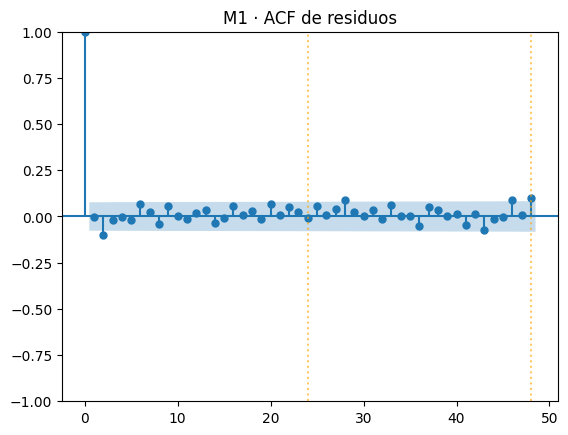

In [ ]:
fig_acf_resM1 = plot_acf(
    resid_M1, lags=48,
    title="M1 · ACF de residuos",
)
for _k in (24, 48):
    fig_acf_resM1.axes[0].axvline(_k, color="orange", linestyle=":", alpha=0.6)
fig_acf_resM1

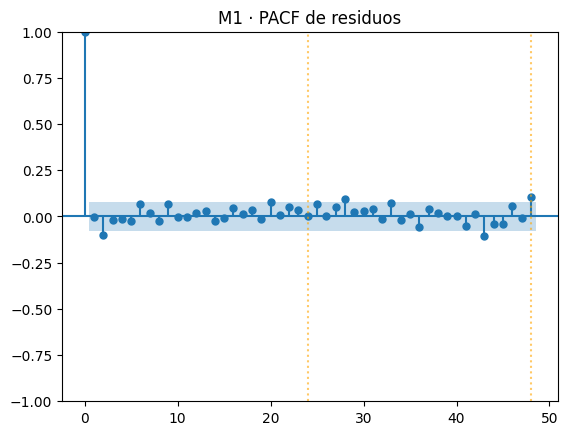

In [ ]:
fig_pacf_resM1 = plot_pacf(
    resid_M1, lags=48, method="ywm",
    title="M1 · PACF de residuos",
)
for _k in (24, 48):
    fig_pacf_resM1.axes[0].axvline(_k, color="orange", linestyle=":", alpha=0.6)
fig_pacf_resM1

#### ¿Qué es un QQ-plot?

"QQ" = **quantile-quantile**. Es una gráfica para responder *"¿estos
datos siguen una distribución Normal?"* comparando sus cuantiles con los
que tendría una Normal teórica.

**La idea.** Un cuantil es el valor por debajo del cual cae cierto
porcentaje de los datos (la mediana es el cuantil 50%). El QQ-plot
ordena tus residuos, calcula a qué cuantil corresponde cada uno, y los
pone en un eje contra el valor que esa misma posición tendría si los
datos fueran exactamente Normales en el otro eje. Cada punto es un
residuo.

**Cómo se lee:**

- Si los datos son Normales, **todos los puntos caen sobre la diagonal**
  (la recta gris punteada). Cuantil observado = cuantil teórico.
- **Puntos que se curvan en los extremos** (colas) → hay más valores
  extremos de lo que predeciría una Normal: "colas pesadas". Es el caso
  típico de residuos con algún pico grande ocasional.
- **Forma de "S"** → asimetría (la distribución está sesgada).

Estandarizamos los residuos antes —restar la media, dividir entre la
desviación— para compararlos contra una Normal estándar $\mathcal{N}(0,1)$.

> **Para qué nos sirve aquí.** Es solo **informativo**: SARIMA no exige
> que los residuos sean Normales. Si las colas se desvían un poco, los
> intervalos de confianza del forecast son algo optimistas en los
> extremos, nada más. No es motivo para cambiar el modelo.

In [ ]:
resid_std_M1 = (resid_M1 - resid_M1.mean()) / resid_M1.std()
qt_M1, qs_M1 = stats.probplot(resid_std_M1, dist="norm", fit=False)

fig_qq_M1 = px.scatter(
    x=qt_M1, y=qs_M1,
    labels={"x": "cuantil teórico (N(0,1))",
            "y": "cuantil muestral"},
    title="M1 · QQ-plot de residuos estandarizados",
)
_lim = max(abs(qt_M1).max(), abs(qs_M1).max())
fig_qq_M1.add_shape(
    type="line", x0=-_lim, x1=_lim, y0=-_lim, y1=_lim,
    line=dict(dash="dash", color="grey"),
)
fig_qq_M1

<marimo-plotly data-figure='{"data":[{"hovertemplate":"cuantil teórico (N(0,1))=%{x}<br>cuantil muestral=%{y}<extra></extra>","legendgroup":"","marker":{"color":"#636efa","symbol":"circle"},"mode":"markers","name":"","orientation":"v","showlegend":false,"x":{"dtype":"f8","bdata":"htS09QqQCMBd8LDAKFwGwPN+MUsOIAXAYHljkmZABMA5pZqFdpEDwKj+nFjfAAPAJY+MVxqFAsCIaJjJjRgCwJ2T4qyktwHA/n/Qt+9fAcAhpL1Msw8BwAL8vQ+oxQDAHzfOSdWAAMC/Yx9seUAAwA3KHsT6AwDAiIcSVLqV/79a8gCrdSn/v8T3hoJ+wv6/NRaT40Zg/r9FhcJhVgL+v2sNiOxFqP2/FhJWmbxR/b/vBTYkbf78vywDJPgTrvy/dL7mnXVg/L8bkEV5XRX8v+TF4MKczPu/Db51sQmG+7/XzpfIfkH7vwB7REXa/vq/zNh3ov29+r/38TIxzX76v0jDYMAvQfq/EHTFUQ4F+r94CbbZU8r5v557yAftkPm/p9IEF8hY+b/Ox2Wk1CH5v0nArooD7Pi/siDJwka3+L8LbP5HkYP4v+ZEgf/WUPi/JqrOogwf+L8ByIOsJ+73v1NNVEcevve/9xHaPueO97+bggHyeWD3v+0k30bOMve/bPDBn9wF979BcFzRndn2v5zf4xkLrva/h98IGR6D9r93J7HI0Fj2v+/DXHYdL/a/VDIkvf4F9r+Y/z6Ab931v0iSBOZqtfW/0oNaU+yN9b/fa4Vn72b1vwlNUvhvQPW/8/GPDmoa9b8+hdDi2fT0v9KJbNq7z/S/sBjBhAyr9L+e8aOYyIb0v5Z/CPLsYvS/MnTRj3Y/9L+xD8uRYhz0v/eQyjau+fO/raLv2lbX878y6gT2WbXzv0ok/Rm1k/O/SnqK8WVy87/w8s0+alHzv1sUHdq/MPO/nPnbsGQQ87/PRmrEVvDyv56KISmU0PK/5bxjBRux8r9Pp7iQ6ZHyv2Ef+RL+cvK/3hCH41ZU8r+WbZFo8jXyv5IqYxbPF/K/sIS8buv58b+d1jUARtzxv6RYq2XdvvG/KjCxRbCh8b+tQA9SvYTxv/M6REcDaPG/f3EP7IBL8b8XAgERNS/xv/PsD5AeE/G/b7k1TDz38L99Tw8xjdvwv1CzgjIQwPC/nFZpTMSk8L9yuD6CqInwv2oR0967bvC/ms4BdP1T8L8qomtabDnwv+nzM7EHH/C/QoDBnc4E8L/+7QOXgNXvv/3cYNe3oe+/dgU9akFu77+w9P/HGzvvvx+ccXNFCO+/4OJa+bzV7r86eyrwgKPuvy/CnfePce6/2nFtuOg/7r/Z8/3jiQ7uv90iEzRy3e2/fk6HaqCs7b+CVgVRE3ztv4K1xbjJS+2/JFVOesIb7b90CDV1/Ovsv8mK5I92vOy/uONjty+N7L89EiDfJl7svwjjtwBbL+y/aNfJG8sA7L+8A8Q1dtLrv9TNtVlbpOu/w3QjmHl2678HTdsG0EjrvwedzMBdG+u/ygbg5SHu6r8gbdGaG8HqvxdDCwlKlOq/ozWDXqxn6r83IJjNQTvqv7w98YwJD+q/IIhe1wLj6b91ObrrLLfpvzNiywyHi+m/vYgpgRBg6b8LRyGTyDTpv7jbmZCuCem/XqT7ysHe6L+GdxeXAbTovxXVDk1tiei/WuQ8SARf6L+BNyDnxTTov09MRYuxCui/18Ixmcbg57+bQlB4BLfnv4sH3ZJqjee/CxDTVfhj57/l5dkwrTrnvwf8M5aIEee/g5ut+ono5r8eWozVsL/mv20Vf6D8lua/XG2O12xu5r9xuQ35AEbmvx10jIW4Hea/4BfI/5L15b/1aZ7sj83lv40uANOupeW/2kLkO+995b8NGTuyUFblv/KS4sLSLuW/uDea/HQH5b+cwffvNuDkv3wAXC8YueS/QA7oThiS5L9B0nLkNmvkvwbRfodzROS/nUUw0c0d5L8WgkNcRffjv7mUA8XZ0OO/oS9BqYqq479v0EmoV4TjvwQm32JAXuO/O7Iue0Q44792pcmUYxLjv1LynFSd7OK/iZfpYPHG4r81Hj1hX6Hiv+ZKav7me+K/z/+B4odW4r9mTsy4QTHivya3wS0UDOK/x5UE7/7m4b+ouFqrAcLhv/ghpxIcneG/bfHj1U144b8ZdRynllPhv19gZzn2LuG/pSfhQGwK4b/Of6Zy+OXgv0cAz4SaweC/quZnLlKd4L/s+m4nH3ngvyeTzSgBVeC/87VT7Pcw4L+DWrMsAw3gv0OL90pF0t+/DgUqJqyK37/67XZlOkPfv5Yj94Tv+96/fiVbAsu03r8e1+JczG3ev8pxVRXzJt6/nKX5rT7g3b/v542qrpndvxbuQJBCU92//1Kq5fkM3b+aZsMy1Mbcv/Ul4ADRgNy/lFqo2u863L9D4BBMMPXbvzcQVeKRr9u/OlDwKxRq279BxZe4tiTbvz0oNBl539q/GLzb31qa2r9MZMyfW1Xav9/aZe16ENq/DgUkXrjL2b/QZZmIE4fZv2itaQSMQtm/GGVEaiH+2L9wtt9T07nYv0tN81uhddi/1lMzHosx2L/nh0s3kO3XvxVp2kSwqde/sX5s5epl1787tXe4PyLXv5DSVl6u3ta/NQBFeDab1r9Ma1mo11fWv335gpGRFNa/VhKE12PR1b+kfO4eTo7VvyJPHw1QS9W/IfQ6SGkI1b+ZPyl3mcXUvxeXkUHggtS/NCvXTz1A1L8eQhVLsP3Tv4mSG904u9O/8q5qsNZ407+UgDBwiTbTv5vRRMhQ9NK/XeYlZSyy0r8iJfXzG3DSv/rLcyIfLtK/f7T/njXs0b8PJZAYX6rRv/qusj6baNG/lhmIwekm0b/HWcFRSuXQv3+VnKC8o9C/LDPiX0Bi0L+k9OFB1SDQv0k64PL1vs+/rETFc2I8z7/czxxu77nOvx4LiUqcN86/ni2fcmi1zb8eKuJQUzPNv4x1vVBcscy/U+B/3oIvzL/QgVZnxq3LvyK1R1kmLMu/XScuI6Kqyr9N9rM0OSnKv1vfTf7qp8m/Vn428bYmyb+Qm2l/nKXIv7+InxubJMi/iIxIObKjx78WXIhM4SLHv0CiMconosa/HZTBJ4Uhxr+Jklvb+KDFv/vXxFuCIMW/1zJgICGgxL80yymh1B/Ev1v0slacn8O/Sgkeuncfw7/aUxpFZp/Cv3T+33FnH8K/5A8su3qfwb+2cDycnx/Bvz/6y5DVn8C/to4OFRwgwL8AdFpL5UC/v0e2hH+xQb6/4KurwZtCvb/MmLINo0O8v9y/SGDGRLu/tvPhtgRGur+zNa8PXUe5v4til2nOSLi/DOwvxFdKt7/rnrUf+Eu2v8F0BX2uTbW/gHGV3XlPtL9ei21DWVGzv2CdILFLU7K/y2PFKVBVsb9vge+wZVewv1UcUZUWs66/X1vS9n+3rL9xWySQBbyqv9FXy2ulwKi/9YQAlV3Fpr/VdaQXLMqkv6qNMQAPz6K/VXyuWwTUoL/th0FvFLKdv/WP/kM9vJm/I8hJUn/Glb/eEoa31tCRv9qKUSN/tou/J/Q9/mvLg781pMt62MB3v7eWFPfAq1+/t5YU98CrXz+Uo8t62MB3P9fzPf5ry4M/KotRI3+2iz/eEoa31tCRPyPISVJ/xpU/9Y/+Qz28mT/Fh0FvFLKdP0F8rlsE1KA/vo0xAA/Poj/VdaQXLMqkP/WEAJVdxaY/0VfLa6XAqD9dWySQBbyqP0tb0vZ/t6w/aRxRlRazrj9vge+wZVewP8tjxSlQVbE/YJ0gsUtTsj9Ui21DWVGzP3Zxld15T7Q/y3QFfa5NtT/rnrUf+Eu2PwzsL8RXSrc/i2KXac5

**Lectura del diagnóstico de M1.**

- **Residuos en el tiempo** — centrados en 0, sin tendencia visible,
  sin varianza creciente. Bien.
- **QQ-plot** — los puntos siguen la diagonal en el centro pero se
  desvían en las colas (residuos extremos más grandes de lo que
  pediría una Normal). Aceptable: SARIMA no exige normalidad.
- **ACF / PACF de residuos** — la mayoría de los lags están dentro
  de la banda gris ✓. Pero **quedan picos pequeños** en lags 24 y 48
  (estacionales) y en lag 2 (no estacional). Eso indica estructura
  que M1 no capturó.
- **Ljung-Box** — al lag 24 y 48 la `p` está por encima de 0.05; al
  lag 10 está justo. Hay margen para mejorar.

Esa señal residual es justo lo que vamos a perseguir con M2 y M3 —
pero primero, dos pasos: en §5 empacamos lo de arriba en helpers
para no repetir 12 celdas por modelo, y en §6 leemos el **recetario**
que nos dice qué perilla mover.

## 5 · Helpers — el mismo flujo, en funciones reusables

Ya vimos cada pieza en §4 (fit, forecast, métricas, residuos limpios,
Ljung-Box, plots de diagnóstico). Las **empacamos** en tres funciones
para reutilizarlas con M2 y M3 sin reescribir las 12 celdas:

- `fit_eval(order, seasonal_order, name)` → ajusta, hace forecast de
  24 h y devuelve un `dict` con `res`, `pred`, `ci`, `resid_clean`,
  AIC, BIC, log-lik, RMSE, MAE, MAPE y Ljung-Box a varios lags.
- `plot_forecast(rec)` → cola del train + holdout + forecast + IC 95%.
- `plot_diagnostics(rec)` → panel 2×2 con residuos, ACF, PACF, QQ.

Cada función hace **exactamente** lo que hicimos a mano arriba, solo
parametrizado por el orden del modelo.

In [ ]:
def fit_eval(order, seasonal_order, name):
    res = SARIMAX(
        train, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=True, enforce_invertibility=True,
    ).fit(disp=False)

    fc = res.get_forecast(steps=len(test))
    pred = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)

    err = pred.values - test.values
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae  = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err / test.values))) * 100

    resid_clean = res.resid.iloc[24:]      # mismo burn-in que en §4
    n_free = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]
    lb = acorr_ljungbox(
        resid_clean, lags=[10, 24, 48],
        model_df=n_free, return_df=True,
    )

    return {
        "name": name,
        "order": order,
        "seasonal_order": seasonal_order,
        "n_params": len(res.params),
        "AIC": float(res.aic),
        "BIC": float(res.bic),
        "loglik": float(res.llf),
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape,
        "LB(10)_p": float(lb["lb_pvalue"].iloc[0]),
        "LB(24)_p": float(lb["lb_pvalue"].iloc[1]),
        "LB(48)_p": float(lb["lb_pvalue"].iloc[2]),
        "res": res,
        "pred": pred,
        "ci": ci,
        "resid_clean": resid_clean,
    }

In [ ]:
def plot_forecast(rec, title=None):
    tail = train.iloc[-72:]
    pred = rec["pred"]; ci = rec["ci"]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=tail.index, y=tail.values,
        mode="lines", name="train (cola)",
        line=dict(color="#2b6cb0", width=1.2),
    ))
    fig.add_trace(go.Scatter(
        x=test.index, y=test.values,
        mode="lines+markers", name="holdout real",
        line=dict(color="#d97706", width=2),
    ))
    fig.add_trace(go.Scatter(
        x=pred.index, y=pred.values,
        mode="lines+markers", name="forecast",
        line=dict(color="#15803d", width=2, dash="dash"),
    ))
    fig.add_trace(go.Scatter(
        x=list(pred.index) + list(pred.index[::-1]),
        y=list(ci.iloc[:, 1].values) + list(ci.iloc[:, 0].values[::-1]),
        fill="toself", fillcolor="rgba(21,128,61,0.15)",
        line=dict(width=0), name="IC 95%", hoverinfo="skip",
    ))
    fig.update_layout(
        title=title or f"{rec['name']} · forecast 24 h vs holdout",
        xaxis_title="fecha", yaxis_title="tdb (°C)",
        template="plotly_white",
        height=360, margin=dict(l=40, r=20, t=50, b=40),
    )
    return fig

In [ ]:
def plot_diagnostics(rec):
    r = rec["resid_clean"].values
    n = len(r)
    ci = 1.96 / np.sqrt(n)
    nlags = 48

    a = acf(r, nlags=nlags, fft=True)
    p = pacf(r, nlags=nlags, method="ywm")

    rs = (r - r.mean()) / r.std()
    qt, qs = stats.probplot(rs, dist="norm", fit=False)

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "Residuos en el tiempo",
            "QQ-plot (residuos estandarizados vs Normal)",
            "ACF de residuos",
            "PACF de residuos",
        ),
    )
    fig.add_trace(go.Scatter(
        x=rec["resid_clean"].index, y=r,
        mode="lines", line=dict(color="#2b6cb0", width=0.8),
        showlegend=False,
    ), row=1, col=1)
    fig.add_hline(y=0, line=dict(color="grey", dash="dash"), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=qt, y=qs, mode="markers",
        marker=dict(color="#2b6cb0", size=4), showlegend=False,
    ), row=1, col=2)
    _lim = max(abs(qt).max(), abs(qs).max())
    fig.add_trace(go.Scatter(
        x=[-_lim, _lim], y=[-_lim, _lim],
        mode="lines", line=dict(color="grey", dash="dash"),
        showlegend=False,
    ), row=1, col=2)

    for _col, _v in enumerate([a, p], start=1):
        fig.add_trace(go.Bar(
            x=list(range(len(_v))), y=_v, marker_color="#2b6cb0",
            hovertemplate="lag=%{x}<br>r=%{y:.3f}<extra></extra>",
            showlegend=False,
        ), row=2, col=_col)
        fig.add_hline(y=ci,  line=dict(dash="dash", color="grey"), row=2, col=_col)
        fig.add_hline(y=-ci, line=dict(dash="dash", color="grey"), row=2, col=_col)
        for _k in (24, 48):
            fig.add_vline(x=_k, line=dict(color="orange", width=1, dash="dot"),
                          row=2, col=_col)

    fig.update_layout(
        title=f"{rec['name']} · diagnóstico de residuos",
        template="plotly_white",
        height=640, margin=dict(l=40, r=20, t=70, b=40),
    )
    fig.update_xaxes(title_text="lag (horas)", row=2, col=1)
    fig.update_xaxes(title_text="lag (horas)", row=2, col=2)
    return fig

### Sanity check — `fit_eval` reproduce M1

Para asegurarnos de que los helpers hacen lo mismo que hicimos a
mano, los aplicamos a M1 y comparamos. Las métricas tienen que
coincidir con las de §4.4.

In [ ]:
M1 = fit_eval(order=(1, 0, 1), seasonal_order=(1, 1, 1, 24), name="M1")
print(
    f"M1 vía helper:\n"
    f"  AIC={M1['AIC']:.2f}  BIC={M1['BIC']:.2f}  log-lik={M1['loglik']:.2f}\n"
    f"  RMSE={M1['RMSE']:.3f}  MAE={M1['MAE']:.3f}  MAPE={M1['MAPE_%']:.2f}%\n"
    f"  LB(10) p={M1['LB(10)_p']:.4f}  "
    f"LB(24) p={M1['LB(24)_p']:.4f}  "
    f"LB(48) p={M1['LB(48)_p']:.4f}"
)

M1 vía helper:
  AIC=1076.97  BIC=1099.33  log-lik=-533.48
  RMSE=1.414  MAE=1.161  MAPE=4.38%
  LB(10) p=0.0372  LB(24) p=0.2715  LB(48) p=0.0634


## 6 · Recetario de iteración

Las reglas para mover las perillas leyendo los **diagnósticos del modelo
anterior**:

| Lo que ves en el residual | Qué mover |
|---|---|
| Pico significativo en **ACF**, lag pequeño (1–3) | sube **`q`** |
| Pico significativo en **PACF**, lag pequeño (1–3) | sube **`p`** |
| Pico significativo en **ACF**, lag `s, 2s` | sube **`Q`** |
| Pico significativo en **PACF**, lag `s, 2s` | sube **`P`** |
| Ljung-Box `p < 0.05` | aún hay estructura → sigue iterando |
| AIC sube al añadir un parámetro | sobreajuste → quítalo |
| Coeficiente con `P>|z| > 0.1` | término redundante → quítalo |

> **Heurística general.** Sube **un parámetro a la vez**. Si el AIC baja
> y el coeficiente nuevo es significativo, lo aceptas. Si no, lo
> revertes. Es búsqueda local guiada por evidencia, no fuerza bruta.

## 7 · Modelo **M2** — `SARIMA(1, 0, 1)(2, 1, 1)₂₄`

**Lectura de M1 que motiva M2.** Quedaba un pico residual en el **lag
24** del ACF/PACF. Eso apunta a que falta memoria estacional adicional.
Las opciones son subir `P` o subir `Q`. Como en la PACF del residuo el
pico cerca de `s` es ligeramente más visible que en la ACF, probamos
**subir `P` de 1 a 2** y dejar el resto igual.

In [ ]:
M2 = fit_eval(order=(1, 0, 1), seasonal_order=(2, 1, 1, 24), name="M2")
print(M2["res"].summary())

                                     SARIMAX Results                                      
Dep. Variable:                                tdb   No. Observations:                  672
Model:             SARIMAX(1, 0, 1)x(2, 1, 1, 24)   Log Likelihood                -526.789
Date:                            Wed, 27 May 2026   AIC                           1065.577
Time:                                    11:50:03   BIC                           1092.420
Sample:                                03-15-2024   HQIC                          1075.990
                                     - 04-11-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8855      0.020     44.845      0.000       0.847       0.924
ma.L1          0.0183      0.041   

In [ ]:
plot_forecast(M2)

<marimo-plotly data-figure='{"data":[{"line":{"color":"#2b6cb0","width":1.2},"mode":"lines","name":"train (cola)","x":["2024-04-09T00:00:00.000000","2024-04-09T01:00:00.000000","2024-04-09T02:00:00.000000","2024-04-09T03:00:00.000000","2024-04-09T04:00:00.000000","2024-04-09T05:00:00.000000","2024-04-09T06:00:00.000000","2024-04-09T07:00:00.000000","2024-04-09T08:00:00.000000","2024-04-09T09:00:00.000000","2024-04-09T10:00:00.000000","2024-04-09T11:00:00.000000","2024-04-09T12:00:00.000000","2024-04-09T13:00:00.000000","2024-04-09T14:00:00.000000","2024-04-09T15:00:00.000000","2024-04-09T16:00:00.000000","2024-04-09T17:00:00.000000","2024-04-09T18:00:00.000000","2024-04-09T19:00:00.000000","2024-04-09T20:00:00.000000","2024-04-09T21:00:00.000000","2024-04-09T22:00:00.000000","2024-04-09T23:00:00.000000","2024-04-10T00:00:00.000000","2024-04-10T01:00:00.000000","2024-04-10T02:00:00.000000","2024-04-10T03:00:00.000000","2024-04-10T04:00:00.000000","2024-04-10T05:00:00.000000","2024-04-10T06:00:00.000000","2024-04-10T07:00:00.000000","2024-04-10T08:00:00.000000","2024-04-10T09:00:00.000000","2024-04-10T10:00:00.000000","2024-04-10T11:00:00.000000","2024-04-10T12:00:00.000000","2024-04-10T13:00:00.000000","2024-04-10T14:00:00.000000","2024-04-10T15:00:00.000000","2024-04-10T16:00:00.000000","2024-04-10T17:00:00.000000","2024-04-10T18:00:00.000000","2024-04-10T19:00:00.000000","2024-04-10T20:00:00.000000","2024-04-10T21:00:00.000000","2024-04-10T22:00:00.000000","2024-04-10T23:00:00.000000","2024-04-11T00:00:00.000000","2024-04-11T01:00:00.000000","2024-04-11T02:00:00.000000","2024-04-11T03:00:00.000000","2024-04-11T04:00:00.000000","2024-04-11T05:00:00.000000","2024-04-11T06:00:00.000000","2024-04-11T07:00:00.000000","2024-04-11T08:00:00.000000","2024-04-11T09:00:00.000000","2024-04-11T10:00:00.000000","2024-04-11T11:00:00.000000","2024-04-11T12:00:00.000000","2024-04-11T13:00:00.000000","2024-04-11T14:00:00.000000","2024-04-11T15:00:00.000000","2024-04-11T16:00:00.000000","2024-04-11T17:00:00.000000","2024-04-11T18:00:00.000000","2024-04-11T19:00:00.000000","2024-04-11T20:00:00.000000","2024-04-11T21:00:00.000000","2024-04-11T22:00:00.000000","2024-04-11T23:00:00.000000"],"y":{"dtype":"f8","bdata":"l24Sg8A6OEB/arx0k7g3QL+fGi/dRDdA9P3UeOlGNkDzRP0bocw1QJa1OiZ4oDVANV66SQzSNECbUnH24cM2QF9zIWlKFTtA6bSBThvoPEBR/0Yoo5c9QNEi2/l+mj5ATmIQWDnkP0Dmifo3QoFAQPp+arx040BAfYZdAXJfQUCpfyOU0WNBQFFGb8taFUFAq2OCB/NkQEDwYJ6ofzM/QKDTBjptED5AGnYFyL1mPUAUrkfhegQ8QGDl0CLbiTpARyijt2XtOEAtsp3vpyY4QBeSplSc7TVAQhm9LWt1NUAeEzyYJ7o0QEw3iUFgJTRAxdmHz7C7M0ArhxbZzvc1QOaJ+jdC6TlAEFg5tMhmOkBmZmZmZiY8QGDl0CLbeT1AS8XZh8+QPkDOPnyGXQFAQA4tsp3vl0BA0pSKsw/3QEB0kxgEVhZBQGZmZmZmrkBAsp3vp8YLQEBDi2zn+9k+QBsv3SQGsT1AnTbQaQMdO0DNzMzMzCw5QPEZdgXIfThAj8L1KFzPN0ADnTbQaZM3QJWKsw+fATdABci95kLCNkCLbOf7qVE2QHnpJjEIzDVAZx8+w67gNEDday4kTfk3QBERERER0TpAJQaBlUOrOkDZFSD3mks8QLNWxwQPtj1A20CnDXTKPkAmeDBP1G8/QHNoke18V0BAvuZC0pTSQEDSlIqzDw9BQN0kBoGVG0FAXNbqmOBZQECbC0lTKg4/QMcED+aJ2jxAp8ZLN4mhO0DVMcGDeVI6QL7mQtKUmjlA"},"type":"scatter"},{"line":{"color":"#d97706","width":2},"mode":"lines+markers","name":"holdout real","x":["2024-04-12T00:00:00.000000","2024-04-12T01:00:00.000000","2024-04-12T02:00:00.000000","2024-04-12T03:00:00.000000","2024-04-12T04:00:00.000000","2024-04-12T05:00:00.000000","2024-04-12T06:00:00.000000","2024-04-12T07:00:00.000000","2024-04-12T08:00:00.000000","2024-04-12T09:00:00.000000","2024-04-12T10:00:00.000000","2024-04-12T11:00:00.000000","2024-04-12T12:00:00.000000","2024-04-12T13:00:00.000000","2024-04-12T14:00:00.000000","2024-04-12T15:00:00.000000","2024-04-12T16:00:00.000000","2024-04-12T17:00:00.000000","2024-04-12T18:00:00.000000","2024-04-12T19:00:00.000000","2024-04-12T20:00:00.000000","2024-04-12T21:00:00.000000","2024-04-12T22:00:00.000000","2024-04-12T23:00:00.000000"],"y":{"dtype":"f8","bdata":"TxvotIGuOEBgLPnFkr83QJVDi2zn6zZA001iEFgZNkB1TPBgnmg1QLy7u7u7WzRAKVyPwvW4M0A20GkDnaY0QCuHFtnOFzhAQ4ts5/v5OEDAyqFFtrM6QE/UvxHKSDxA8oslv1jCPUDOPnyGXUE/QP0boYze5j9AV4Dc

In [ ]:
print(
    f"M2  {M2['order']}{M2['seasonal_order']}\n"
    f"  n_params={M2['n_params']}  log-lik={M2['loglik']:.2f}\n"
    f"  AIC={M2['AIC']:.2f}   BIC={M2['BIC']:.2f}\n"
    f"  RMSE={M2['RMSE']:.3f}   MAE={M2['MAE']:.3f}   MAPE={M2['MAPE_%']:.2f}%\n"
    f"  Ljung-Box (residuos):\n"
    f"    lag 10: p={M2['LB(10)_p']:.4f}\n"
    f"    lag 24: p={M2['LB(24)_p']:.4f}\n"
    f"    lag 48: p={M2['LB(48)_p']:.4f}"
)

M2  (1, 0, 1)(2, 1, 1, 24)
  n_params=6  log-lik=-526.79
  AIC=1065.58   BIC=1092.42
  RMSE=1.361   MAE=1.067   MAPE=3.96%
  Ljung-Box (residuos):
    lag 10: p=0.0142
    lag 24: p=0.2123
    lag 48: p=0.1402


In [ ]:
plot_diagnostics(M2)

<marimo-plotly data-figure='{"data":[{"line":{"color":"#2b6cb0","width":0.8},"mode":"lines","showlegend":false,"x":["2024-03-16T00:00:00.000000","2024-03-16T01:00:00.000000","2024-03-16T02:00:00.000000","2024-03-16T03:00:00.000000","2024-03-16T04:00:00.000000","2024-03-16T05:00:00.000000","2024-03-16T06:00:00.000000","2024-03-16T07:00:00.000000","2024-03-16T08:00:00.000000","2024-03-16T09:00:00.000000","2024-03-16T10:00:00.000000","2024-03-16T11:00:00.000000","2024-03-16T12:00:00.000000","2024-03-16T13:00:00.000000","2024-03-16T14:00:00.000000","2024-03-16T15:00:00.000000","2024-03-16T16:00:00.000000","2024-03-16T17:00:00.000000","2024-03-16T18:00:00.000000","2024-03-16T19:00:00.000000","2024-03-16T20:00:00.000000","2024-03-16T21:00:00.000000","2024-03-16T22:00:00.000000","2024-03-16T23:00:00.000000","2024-03-17T00:00:00.000000","2024-03-17T01:00:00.000000","2024-03-17T02:00:00.000000","2024-03-17T03:00:00.000000","2024-03-17T04:00:00.000000","2024-03-17T05:00:00.000000","2024-03-17T06:00:00.000000","2024-03-17T07:00:00.000000","2024-03-17T08:00:00.000000","2024-03-17T09:00:00.000000","2024-03-17T10:00:00.000000","2024-03-17T11:00:00.000000","2024-03-17T12:00:00.000000","2024-03-17T13:00:00.000000","2024-03-17T14:00:00.000000","2024-03-17T15:00:00.000000","2024-03-17T16:00:00.000000","2024-03-17T17:00:00.000000","2024-03-17T18:00:00.000000","2024-03-17T19:00:00.000000","2024-03-17T20:00:00.000000","2024-03-17T21:00:00.000000","2024-03-17T22:00:00.000000","2024-03-17T23:00:00.000000","2024-03-18T00:00:00.000000","2024-03-18T01:00:00.000000","2024-03-18T02:00:00.000000","2024-03-18T03:00:00.000000","2024-03-18T04:00:00.000000","2024-03-18T05:00:00.000000","2024-03-18T06:00:00.000000","2024-03-18T07:00:00.000000","2024-03-18T08:00:00.000000","2024-03-18T09:00:00.000000","2024-03-18T10:00:00.000000","2024-03-18T11:00:00.000000","2024-03-18T12:00:00.000000","2024-03-18T13:00:00.000000","2024-03-18T14:00:00.000000","2024-03-18T15:00:00.000000","2024-03-18T16:00:00.000000","2024-03-18T17:00:00.000000","2024-03-18T18:00:00.000000","2024-03-18T19:00:00.000000","2024-03-18T20:00:00.000000","2024-03-18T21:00:00.000000","2024-03-18T22:00:00.000000","2024-03-18T23:00:00.000000","2024-03-19T00:00:00.000000","2024-03-19T01:00:00.000000","2024-03-19T02:00:00.000000","2024-03-19T03:00:00.000000","2024-03-19T04:00:00.000000","2024-03-19T05:00:00.000000","2024-03-19T06:00:00.000000","2024-03-19T07:00:00.000000","2024-03-19T08:00:00.000000","2024-03-19T09:00:00.000000","2024-03-19T10:00:00.000000","2024-03-19T11:00:00.000000","2024-03-19T12:00:00.000000","2024-03-19T13:00:00.000000","2024-03-19T14:00:00.000000","2024-03-19T15:00:00.000000","2024-03-19T16:00:00.000000","2024-03-19T17:00:00.000000","2024-03-19T18:00:00.000000","2024-03-19T19:00:00.000000","2024-03-19T20:00:00.000000","2024-03-19T21:00:00.000000","2024-03-19T22:00:00.000000","2024-03-19T23:00:00.000000","2024-03-20T00:00:00.000000","2024-03-20T01:00:00.000000","2024-03-20T02:00:00.000000","2024-03-20T03:00:00.000000","2024-03-20T04:00:00.000000","2024-03-20T05:00:00.000000","2024-03-20T06:00:00.000000","2024-03-20T07:00:00.000000","2024-03-20T08:00:00.000000","2024-03-20T09:00:00.000000","2024-03-20T10:00:00.000000","2024-03-20T11:00:00.000000","2024-03-20T12:00:00.000000","2024-03-20T13:00:00.000000","2024-03-20T14:00:00.000000","2024-03-20T15:00:00.000000","2024-03-20T16:00:00.000000","2024-03-20T17:00:00.000000","2024-03-20T18:00:00.000000","2024-03-20T19:00:00.000000","2024-03-20T20:00:00.000000","2024-03-20T21:00:00.000000","2024-03-20T22:00:00.000000","2024-03-20T23:00:00.000000","2024-03-21T00:00:00.000000","2024-03-21T01:00:00.000000","2024-03-21T02:00:00.000000","2024-03-21T03:00:00.000000","2024-03-21T04:00:00.000000","2024-03-21T05:00:00.000000","2024-03-21T06:00:00.000000","2024-03-21T07:00:00.000000","2024-03-21T08:00:00.000000","2024-03-21T09:00:00.000000","2024-03-21T10:00:00.000000","2024-03-21T11:00:00.000000","2024-03-21T12:00:00.000000","2024-03-21T13:00:00.000000

**Lectura de M2 vs M1.**

- **AIC bajó** respecto a M1 (la baja de AIC ya justifica el parámetro
  extra).
- **RMSE en holdout también bajó** un poco — el modelo pronostica mejor
  las 24 horas siguientes.
- **`ar.S.L48`** (el nuevo término `P = 2`) sale significativo: aporta.
- **ACF/PACF de residuos** — el pico del lag 24 se redujo. Sigue
  habiendo algo de estructura en lags pequeños (2–3) que podríamos
  atacar con `q` o `p`.

Eso motiva M3.

## 8 · Modelo **M3** — `SARIMA(2, 0, 2)(2, 1, 1)₂₄`

**Lectura de M2 que motiva M3.** Los residuos de M2 todavía muestran un
pico negativo en lag 2 del ACF y la PACF. Es estructura no estacional
que ni `p = 1` ni `q = 1` están capturando. Subimos **ambos a 2**,
manteniendo el bloque estacional `(2, 1, 1, 24)` de M2.

In [ ]:
M3 = fit_eval(order=(2, 0, 2), seasonal_order=(2, 1, 1, 24), name="M3")
print(M3["res"].summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  tdb   No. Observations:                  672
Model:             SARIMAX(2, 0, 2)x(2, 1, [1], 24)   Log Likelihood                -519.672
Date:                              Wed, 27 May 2026   AIC                           1055.345
Time:                                      11:50:08   BIC                           1091.136
Sample:                                  03-15-2024   HQIC                          1069.229
                                       - 04-11-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6505      0.100     16.574      0.000       1.455       1.846
ar.L2         -0.65

In [ ]:
plot_forecast(M3)

<marimo-plotly data-figure='{"data":[{"line":{"color":"#2b6cb0","width":1.2},"mode":"lines","name":"train (cola)","x":["2024-04-09T00:00:00.000000","2024-04-09T01:00:00.000000","2024-04-09T02:00:00.000000","2024-04-09T03:00:00.000000","2024-04-09T04:00:00.000000","2024-04-09T05:00:00.000000","2024-04-09T06:00:00.000000","2024-04-09T07:00:00.000000","2024-04-09T08:00:00.000000","2024-04-09T09:00:00.000000","2024-04-09T10:00:00.000000","2024-04-09T11:00:00.000000","2024-04-09T12:00:00.000000","2024-04-09T13:00:00.000000","2024-04-09T14:00:00.000000","2024-04-09T15:00:00.000000","2024-04-09T16:00:00.000000","2024-04-09T17:00:00.000000","2024-04-09T18:00:00.000000","2024-04-09T19:00:00.000000","2024-04-09T20:00:00.000000","2024-04-09T21:00:00.000000","2024-04-09T22:00:00.000000","2024-04-09T23:00:00.000000","2024-04-10T00:00:00.000000","2024-04-10T01:00:00.000000","2024-04-10T02:00:00.000000","2024-04-10T03:00:00.000000","2024-04-10T04:00:00.000000","2024-04-10T05:00:00.000000","2024-04-10T06:00:00.000000","2024-04-10T07:00:00.000000","2024-04-10T08:00:00.000000","2024-04-10T09:00:00.000000","2024-04-10T10:00:00.000000","2024-04-10T11:00:00.000000","2024-04-10T12:00:00.000000","2024-04-10T13:00:00.000000","2024-04-10T14:00:00.000000","2024-04-10T15:00:00.000000","2024-04-10T16:00:00.000000","2024-04-10T17:00:00.000000","2024-04-10T18:00:00.000000","2024-04-10T19:00:00.000000","2024-04-10T20:00:00.000000","2024-04-10T21:00:00.000000","2024-04-10T22:00:00.000000","2024-04-10T23:00:00.000000","2024-04-11T00:00:00.000000","2024-04-11T01:00:00.000000","2024-04-11T02:00:00.000000","2024-04-11T03:00:00.000000","2024-04-11T04:00:00.000000","2024-04-11T05:00:00.000000","2024-04-11T06:00:00.000000","2024-04-11T07:00:00.000000","2024-04-11T08:00:00.000000","2024-04-11T09:00:00.000000","2024-04-11T10:00:00.000000","2024-04-11T11:00:00.000000","2024-04-11T12:00:00.000000","2024-04-11T13:00:00.000000","2024-04-11T14:00:00.000000","2024-04-11T15:00:00.000000","2024-04-11T16:00:00.000000","2024-04-11T17:00:00.000000","2024-04-11T18:00:00.000000","2024-04-11T19:00:00.000000","2024-04-11T20:00:00.000000","2024-04-11T21:00:00.000000","2024-04-11T22:00:00.000000","2024-04-11T23:00:00.000000"],"y":{"dtype":"f8","bdata":"l24Sg8A6OEB/arx0k7g3QL+fGi/dRDdA9P3UeOlGNkDzRP0bocw1QJa1OiZ4oDVANV66SQzSNECbUnH24cM2QF9zIWlKFTtA6bSBThvoPEBR/0Yoo5c9QNEi2/l+mj5ATmIQWDnkP0Dmifo3QoFAQPp+arx040BAfYZdAXJfQUCpfyOU0WNBQFFGb8taFUFAq2OCB/NkQEDwYJ6ofzM/QKDTBjptED5AGnYFyL1mPUAUrkfhegQ8QGDl0CLbiTpARyijt2XtOEAtsp3vpyY4QBeSplSc7TVAQhm9LWt1NUAeEzyYJ7o0QEw3iUFgJTRAxdmHz7C7M0ArhxbZzvc1QOaJ+jdC6TlAEFg5tMhmOkBmZmZmZiY8QGDl0CLbeT1AS8XZh8+QPkDOPnyGXQFAQA4tsp3vl0BA0pSKsw/3QEB0kxgEVhZBQGZmZmZmrkBAsp3vp8YLQEBDi2zn+9k+QBsv3SQGsT1AnTbQaQMdO0DNzMzMzCw5QPEZdgXIfThAj8L1KFzPN0ADnTbQaZM3QJWKsw+fATdABci95kLCNkCLbOf7qVE2QHnpJjEIzDVAZx8+w67gNEDday4kTfk3QBERERER0TpAJQaBlUOrOkDZFSD3mks8QLNWxwQPtj1A20CnDXTKPkAmeDBP1G8/QHNoke18V0BAvuZC0pTSQEDSlIqzDw9BQN0kBoGVG0FAXNbqmOBZQECbC0lTKg4/QMcED+aJ2jxAp8ZLN4mhO0DVMcGDeVI6QL7mQtKUmjlA"},"type":"scatter"},{"line":{"color":"#d97706","width":2},"mode":"lines+markers","name":"holdout real","x":["2024-04-12T00:00:00.000000","2024-04-12T01:00:00.000000","2024-04-12T02:00:00.000000","2024-04-12T03:00:00.000000","2024-04-12T04:00:00.000000","2024-04-12T05:00:00.000000","2024-04-12T06:00:00.000000","2024-04-12T07:00:00.000000","2024-04-12T08:00:00.000000","2024-04-12T09:00:00.000000","2024-04-12T10:00:00.000000","2024-04-12T11:00:00.000000","2024-04-12T12:00:00.000000","2024-04-12T13:00:00.000000","2024-04-12T14:00:00.000000","2024-04-12T15:00:00.000000","2024-04-12T16:00:00.000000","2024-04-12T17:00:00.000000","2024-04-12T18:00:00.000000","2024-04-12T19:00:00.000000","2024-04-12T20:00:00.000000","2024-04-12T21:00:00.000000","2024-04-12T22:00:00.000000","2024-04-12T23:00:00.000000"],"y":{"dtype":"f8","bdata":"TxvotIGuOEBgLPnFkr83QJVDi2zn6zZA001iEFgZNkB1TPBgnmg1QLy7u7u7WzRAKVyPwvW4M0A20GkDnaY0QCuHFtnOFzhAQ4ts5/v5OEDAyqFFtrM6QE/UvxHKSDxA8oslv1jCPUDOPnyGXUE/QP0boYze5j9AV4Dc

In [ ]:
print(
    f"M3  {M3['order']}{M3['seasonal_order']}\n"
    f"  n_params={M3['n_params']}  log-lik={M3['loglik']:.2f}\n"
    f"  AIC={M3['AIC']:.2f}   BIC={M3['BIC']:.2f}\n"
    f"  RMSE={M3['RMSE']:.3f}   MAE={M3['MAE']:.3f}   MAPE={M3['MAPE_%']:.2f}%\n"
    f"  Ljung-Box (residuos):\n"
    f"    lag 10: p={M3['LB(10)_p']:.4f}\n"
    f"    lag 24: p={M3['LB(24)_p']:.4f}\n"
    f"    lag 48: p={M3['LB(48)_p']:.4f}"
)

M3  (2, 0, 2)(2, 1, 1, 24)
  n_params=8  log-lik=-519.67
  AIC=1055.34   BIC=1091.14
  RMSE=1.334   MAE=1.039   MAPE=3.83%
  Ljung-Box (residuos):
    lag 10: p=0.0570
    lag 24: p=0.6163
    lag 48: p=0.3563


In [ ]:
plot_diagnostics(M3)

<marimo-plotly data-figure='{"data":[{"line":{"color":"#2b6cb0","width":0.8},"mode":"lines","showlegend":false,"x":["2024-03-16T00:00:00.000000","2024-03-16T01:00:00.000000","2024-03-16T02:00:00.000000","2024-03-16T03:00:00.000000","2024-03-16T04:00:00.000000","2024-03-16T05:00:00.000000","2024-03-16T06:00:00.000000","2024-03-16T07:00:00.000000","2024-03-16T08:00:00.000000","2024-03-16T09:00:00.000000","2024-03-16T10:00:00.000000","2024-03-16T11:00:00.000000","2024-03-16T12:00:00.000000","2024-03-16T13:00:00.000000","2024-03-16T14:00:00.000000","2024-03-16T15:00:00.000000","2024-03-16T16:00:00.000000","2024-03-16T17:00:00.000000","2024-03-16T18:00:00.000000","2024-03-16T19:00:00.000000","2024-03-16T20:00:00.000000","2024-03-16T21:00:00.000000","2024-03-16T22:00:00.000000","2024-03-16T23:00:00.000000","2024-03-17T00:00:00.000000","2024-03-17T01:00:00.000000","2024-03-17T02:00:00.000000","2024-03-17T03:00:00.000000","2024-03-17T04:00:00.000000","2024-03-17T05:00:00.000000","2024-03-17T06:00:00.000000","2024-03-17T07:00:00.000000","2024-03-17T08:00:00.000000","2024-03-17T09:00:00.000000","2024-03-17T10:00:00.000000","2024-03-17T11:00:00.000000","2024-03-17T12:00:00.000000","2024-03-17T13:00:00.000000","2024-03-17T14:00:00.000000","2024-03-17T15:00:00.000000","2024-03-17T16:00:00.000000","2024-03-17T17:00:00.000000","2024-03-17T18:00:00.000000","2024-03-17T19:00:00.000000","2024-03-17T20:00:00.000000","2024-03-17T21:00:00.000000","2024-03-17T22:00:00.000000","2024-03-17T23:00:00.000000","2024-03-18T00:00:00.000000","2024-03-18T01:00:00.000000","2024-03-18T02:00:00.000000","2024-03-18T03:00:00.000000","2024-03-18T04:00:00.000000","2024-03-18T05:00:00.000000","2024-03-18T06:00:00.000000","2024-03-18T07:00:00.000000","2024-03-18T08:00:00.000000","2024-03-18T09:00:00.000000","2024-03-18T10:00:00.000000","2024-03-18T11:00:00.000000","2024-03-18T12:00:00.000000","2024-03-18T13:00:00.000000","2024-03-18T14:00:00.000000","2024-03-18T15:00:00.000000","2024-03-18T16:00:00.000000","2024-03-18T17:00:00.000000","2024-03-18T18:00:00.000000","2024-03-18T19:00:00.000000","2024-03-18T20:00:00.000000","2024-03-18T21:00:00.000000","2024-03-18T22:00:00.000000","2024-03-18T23:00:00.000000","2024-03-19T00:00:00.000000","2024-03-19T01:00:00.000000","2024-03-19T02:00:00.000000","2024-03-19T03:00:00.000000","2024-03-19T04:00:00.000000","2024-03-19T05:00:00.000000","2024-03-19T06:00:00.000000","2024-03-19T07:00:00.000000","2024-03-19T08:00:00.000000","2024-03-19T09:00:00.000000","2024-03-19T10:00:00.000000","2024-03-19T11:00:00.000000","2024-03-19T12:00:00.000000","2024-03-19T13:00:00.000000","2024-03-19T14:00:00.000000","2024-03-19T15:00:00.000000","2024-03-19T16:00:00.000000","2024-03-19T17:00:00.000000","2024-03-19T18:00:00.000000","2024-03-19T19:00:00.000000","2024-03-19T20:00:00.000000","2024-03-19T21:00:00.000000","2024-03-19T22:00:00.000000","2024-03-19T23:00:00.000000","2024-03-20T00:00:00.000000","2024-03-20T01:00:00.000000","2024-03-20T02:00:00.000000","2024-03-20T03:00:00.000000","2024-03-20T04:00:00.000000","2024-03-20T05:00:00.000000","2024-03-20T06:00:00.000000","2024-03-20T07:00:00.000000","2024-03-20T08:00:00.000000","2024-03-20T09:00:00.000000","2024-03-20T10:00:00.000000","2024-03-20T11:00:00.000000","2024-03-20T12:00:00.000000","2024-03-20T13:00:00.000000","2024-03-20T14:00:00.000000","2024-03-20T15:00:00.000000","2024-03-20T16:00:00.000000","2024-03-20T17:00:00.000000","2024-03-20T18:00:00.000000","2024-03-20T19:00:00.000000","2024-03-20T20:00:00.000000","2024-03-20T21:00:00.000000","2024-03-20T22:00:00.000000","2024-03-20T23:00:00.000000","2024-03-21T00:00:00.000000","2024-03-21T01:00:00.000000","2024-03-21T02:00:00.000000","2024-03-21T03:00:00.000000","2024-03-21T04:00:00.000000","2024-03-21T05:00:00.000000","2024-03-21T06:00:00.000000","2024-03-21T07:00:00.000000","2024-03-21T08:00:00.000000","2024-03-21T09:00:00.000000","2024-03-21T10:00:00.000000","2024-03-21T11:00:00.000000","2024-03-21T12:00:00.000000","2024-03-21T13:00:00.000000

**Lectura de M3.**

- El AIC vuelve a bajar respecto a M2. La log-verosimilitud sube — el
  modelo se ajusta mejor a los datos.
- El RMSE del holdout puede no bajar tanto como bajó el AIC: ajustar el
  *train* mejor no garantiza pronosticar mejor *fuera*.
- Algunos coeficientes nuevos pueden salir con `P>|z|` alto. Si así
  ocurre, **eso es señal de sobreajuste**: el término ayuda al AIC pero
  no aporta una relación estable.
- Los residuos deberían verse aún más cercanos a ruido blanco; LB en
  lag 10 debería ser más cómodo.

El siguiente paso natural sería **comparar las tres opciones de
frente**.

## 9 · Tabla acumulativa de comparación

Junta los tres modelos. Mira específicamente:

1. Cómo evoluciona el **AIC** (favorece ajuste interno con penalización
   suave).
2. Cómo evoluciona el **BIC** (penaliza más por número de parámetros).
3. Cómo evoluciona el **RMSE del holdout** — la prueba honesta.
4. Las `p` de **Ljung-Box** — semáforo de "queda señal en residuos".

> **Pregunta guía.** ¿El modelo con el AIC más bajo es también el de
> menor RMSE? Si no, ¿qué pesa más para tu problema?

In [ ]:
def _row(m):
    return {
        "modelo": m["name"],
        "orden": f"{m['order']}{m['seasonal_order']}",
        "n_params": m["n_params"],
        "log-lik": round(m["loglik"], 2),
        "AIC": round(m["AIC"], 2),
        "BIC": round(m["BIC"], 2),
        "RMSE": round(m["RMSE"], 3),
        "MAE": round(m["MAE"], 3),
        "MAPE_%": round(m["MAPE_%"], 2),
        "LB(10)_p": round(m["LB(10)_p"], 4),
        "LB(24)_p": round(m["LB(24)_p"], 4),
        "LB(48)_p": round(m["LB(48)_p"], 4),
    }

summary_table = pd.DataFrame([_row(M1), _row(M2), _row(M3)])
summary_table

,modelo,orden,n_params,log-lik,AIC,BIC,RMSE,MAE,MAPE_%,LB(10)_p,LB(24)_p,LB(48)_p
0,M1,"(1, 0, 1)(1, 1, 1, 24)",5,-533.48,1076.97,1099.33,1.414,1.161,4.38,0.0372,0.2715,0.0634
1,M2,"(1, 0, 1)(2, 1, 1, 24)",6,-526.79,1065.58,1092.42,1.361,1.067,3.96,0.0142,0.2123,0.1402
2,M3,"(2, 0, 2)(2, 1, 1, 24)",8,-519.67,1055.34,1091.14,1.334,1.039,3.83,0.0570,0.6163,0.3563


## 10 · Métricas para decidir — lo que mide cada cosa

Ahora que tenemos la tabla, vale la pena nombrar **qué dice cada
columna** para no decidir a ojo.

### AIC vs BIC — penalizaciones de complejidad

Ambos parten del log-likelihood ($\ell$) y le restan una "multa" por el
número de parámetros `k`:

$$
\text{AIC} = -2\,\ell + 2\,k
\qquad
\text{BIC} = -2\,\ell + k\,\log n
$$

- **AIC** penaliza con un `2` constante por parámetro → más permisivo.
- **BIC** penaliza con `log n` (≈ 6.5 para n = 672) → más estricto.

> **AIC más bajo = mejor**. **BIC más bajo = mejor**. Pueden discrepar
> cuando un modelo grande baja `-2ℓ` lo suficiente para compensar al
> AIC pero **no** al BIC. Cuando discrepan, BIC suele preferir el
> modelo más simple — útil contra sobreajuste.

### RMSE / MAE / MAPE en holdout — la prueba honesta

Estas tres miden el error del **forecast** sobre datos que el modelo
**no vio**. AIC y BIC pueden bajar de forma engañosa al añadir
parámetros (sobreajuste); RMSE en holdout no se deja engañar.

- **RMSE** = $\sqrt{\text{mean}(e_t^2)}$ — castiga errores grandes.
- **MAE** = $\text{mean}(|e_t|)$ — promedio simple del error absoluto.
- **MAPE** = $\text{mean}(|e_t/y_t|)\cdot 100$ — error relativo en %.

Un buen modelo SARIMA tiene **RMSE consistentemente bajo en holdout**,
no solo AIC bajo en el train.

### Ljung-Box — semáforo de estructura residual

$H_0$: "los residuos hasta el lag `L` son ruido blanco". Si `p < 0.05`
rechazamos → todavía hay autocorrelación que el modelo no captó.

> **Lectura práctica**: queremos `LB(10)`, `LB(24)` y `LB(48)`
> **todas > 0.05**. Si alguna falla, hay margen para iterar.

### Parsimonia — `n_params`

Empate técnico en AIC/RMSE → **gana el modelo con menos parámetros**.
Es la navaja de Occam aplicada a pronóstico: menos parámetros suelen
generalizar mejor a períodos futuros que no se parecen exactamente al
train.

### El trade-off real

> **AIC más bajo ≠ mejor en holdout.**
>
> Un modelo con muchos parámetros puede minimizar AIC pero pronosticar
> peor las próximas 24 h. Por eso miramos **las tres métricas juntas**:
> AIC/BIC (información interna), RMSE/MAE/MAPE (capacidad predictiva
> real) y Ljung-Box (sanidad del residuo).

## 11 · Decisión final

Mirando la tabla acumulativa y los diagnósticos:

- Si **AIC, BIC y RMSE bajan juntos** de M1 a M2 a M3 y Ljung-Box
  mejora, **M3 es el ganador** con argumentos sólidos.
- Si M3 baja AIC pero **sube BIC y/o RMSE**, está sobreajustado:
  **M2 gana** por parsimonia y mejor pronóstico.
- Si M1 ya tenía Ljung-Box cómodo y los demás solo mejoran AIC marginal,
  **M1 gana** — es el más simple y suficiente.

Para `tdb` en la ventana 2024-03-15 → 2024-04-12, el criterio
recomendado es:

> **Elegir el modelo de menor RMSE en holdout entre los que pasan
> Ljung-Box en lag 24 y 48** (es decir, los que no dejan estructura
> estacional residual). En caso de empate técnico, **el de menos
> parámetros**.

Ese modelo es el que se hereda en `021_tdb_pronostico.py` para estudiar
el comportamiento del forecast a distintos horizontes.

---

### Lo que aprendimos

- El proceso de configurar SARIMA no es magia ni búsqueda ciega:
  **ADF/KPSS → `(d, D)`**, **ACF/PACF → `(p, q, P, Q)`**, **diagnóstico
  de residuos → siguiente iteración**.
- El recetario es local: cambia **un parámetro a la vez**, leyendo el
  residuo del modelo anterior.
- Hay tres familias de métricas que tienen que **decir lo mismo**:
  información (AIC/BIC), predicción (RMSE/MAE/MAPE) y sanidad
  (Ljung-Box). Cuando discrepan, gana la predicción + parsimonia.

## 12 · Vista comparativa final

Para cerrar, dos artefactos visuales que resumen todo el ejercicio:

1. **Una gráfica** con las tres predicciones M1, M2, M3 superpuestas
   contra el holdout real, para ver de un vistazo cuál se ajusta mejor.
2. **La tabla de métricas** con la fila del modelo ganador resaltada.
   Ganador = menor RMSE entre los que **pasan Ljung-Box en los tres
   lags** (10, 24, 48). Si ninguno pasa, gana el de menor RMSE simple.

In [ ]:
serie_comparacion = pd.concat([
    train.iloc[-48:].to_frame("tdb").assign(curva="train (cola, 48 h)"),
    test.to_frame("tdb").assign(curva="holdout real"),
    M1["pred"].to_frame("tdb").assign(curva=f"forecast {M1['name']}"),
    M2["pred"].to_frame("tdb").assign(curva=f"forecast {M2['name']}"),
    M3["pred"].to_frame("tdb").assign(curva=f"forecast {M3['name']}"),
])
fig_comparacion = px.line(
    serie_comparacion, y="tdb", color="curva",
    title="M1 · M2 · M3 — forecast 24 h contra el holdout real",
    labels={"tdb": "tdb (°C)", "date": "fecha"},
)
fig_comparacion

<marimo-plotly data-figure='{"data":[{"hovertemplate":"curva=train (cola, 48 h)<br>index=%{x}<br>tdb (°C)=%{y}<extra></extra>","legendgroup":"train (cola, 48 h)","line":{"color":"#636efa","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"train (cola, 48 h)","orientation":"v","showlegend":true,"x":["2024-04-10T00:00:00.000000","2024-04-10T01:00:00.000000","2024-04-10T02:00:00.000000","2024-04-10T03:00:00.000000","2024-04-10T04:00:00.000000","2024-04-10T05:00:00.000000","2024-04-10T06:00:00.000000","2024-04-10T07:00:00.000000","2024-04-10T08:00:00.000000","2024-04-10T09:00:00.000000","2024-04-10T10:00:00.000000","2024-04-10T11:00:00.000000","2024-04-10T12:00:00.000000","2024-04-10T13:00:00.000000","2024-04-10T14:00:00.000000","2024-04-10T15:00:00.000000","2024-04-10T16:00:00.000000","2024-04-10T17:00:00.000000","2024-04-10T18:00:00.000000","2024-04-10T19:00:00.000000","2024-04-10T20:00:00.000000","2024-04-10T21:00:00.000000","2024-04-10T22:00:00.000000","2024-04-10T23:00:00.000000","2024-04-11T00:00:00.000000","2024-04-11T01:00:00.000000","2024-04-11T02:00:00.000000","2024-04-11T03:00:00.000000","2024-04-11T04:00:00.000000","2024-04-11T05:00:00.000000","2024-04-11T06:00:00.000000","2024-04-11T07:00:00.000000","2024-04-11T08:00:00.000000","2024-04-11T09:00:00.000000","2024-04-11T10:00:00.000000","2024-04-11T11:00:00.000000","2024-04-11T12:00:00.000000","2024-04-11T13:00:00.000000","2024-04-11T14:00:00.000000","2024-04-11T15:00:00.000000","2024-04-11T16:00:00.000000","2024-04-11T17:00:00.000000","2024-04-11T18:00:00.000000","2024-04-11T19:00:00.000000","2024-04-11T20:00:00.000000","2024-04-11T21:00:00.000000","2024-04-11T22:00:00.000000","2024-04-11T23:00:00.000000"],"xaxis":"x","y":{"dtype":"f8","bdata":"Ryijt2XtOEAtsp3vpyY4QBeSplSc7TVAQhm9LWt1NUAeEzyYJ7o0QEw3iUFgJTRAxdmHz7C7M0ArhxbZzvc1QOaJ+jdC6TlAEFg5tMhmOkBmZmZmZiY8QGDl0CLbeT1AS8XZh8+QPkDOPnyGXQFAQA4tsp3vl0BA0pSKsw/3QEB0kxgEVhZBQGZmZmZmrkBAsp3vp8YLQEBDi2zn+9k+QBsv3SQGsT1AnTbQaQMdO0DNzMzMzCw5QPEZdgXIfThAj8L1KFzPN0ADnTbQaZM3QJWKsw+fATdABci95kLCNkCLbOf7qVE2QHnpJjEIzDVAZx8+w67gNEDday4kTfk3QBERERER0TpAJQaBlUOrOkDZFSD3mks8QLNWxwQPtj1A20CnDXTKPkAmeDBP1G8/QHNoke18V0BAvuZC0pTSQEDSlIqzDw9BQN0kBoGVG0FAXNbqmOBZQECbC0lTKg4/QMcED+aJ2jxAp8ZLN4mhO0DVMcGDeVI6QL7mQtKUmjlA"},"yaxis":"y","type":"scatter"},{"hovertemplate":"curva=holdout real<br>index=%{x}<br>tdb (°C)=%{y}<extra></extra>","legendgroup":"holdout real","line":{"color":"#EF553B","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"holdout real","orientation":"v","showlegend":true,"x":["2024-04-12T00:00:00.000000","2024-04-12T01:00:00.000000","2024-04-12T02:00:00.000000","2024-04-12T03:00:00.000000","2024-04-12T04:00:00.000000","2024-04-12T05:00:00.000000","2024-04-12T06:00:00.000000","2024-04-12T07:00:00.000000","2024-04-12T08:00:00.000000","2024-04-12T09:00:00.000000","2024-04-12T10:00:00.000000","2024-04-12T11:00:00.000000","2024-04-12T12:00:00.000000","2024-04-12T13:00:00.000000","2024-04-12T14:00:00.000000","2024-04-12T15:00:00.000000","2024-04-12T16:00:00.000000","2024-04-12T17:00:00.000000","2024-04-12T18:00:00.000000","2024-04-12T19:00:00.000000","2024-04-12T20:00:00.000000","2024-04-12T21:00:00.000000","2024-04-12T22:00:00.000000","2024-04-12T23:00:00.000000"],"xaxis":"x","y":{"dtype":"f8","bdata":"TxvotIGuOEBgLPnFkr83QJVDi2zn6zZA001iEFgZNkB1TPBgnmg1QLy7u7u7WzRAKVyPwvW4M0A20GkDnaY0QCuHFtnOFzhAQ4ts5/v5OEDAyqFFtrM6QE/UvxHKSDxA8oslv1jCPUDOPnyGXUE/QP0boYze5j9AV4Dcay6kQEAEVg4tstVAQB+F61G4rkBAU3H24TMcQEC/nxov3TQ+QEfhehSutz1AWTm0yHbePUAREREREeE8QO/u7u7uXjtA"},"yaxis":"y","type":"scatter"},{"hovertemplate":"curva=forecast M1<br>index=%{x}<br>tdb (°C)=%{y}<extra></extra>","legendgroup":"forecast M1","line":{"color":"#00cc96","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"forecast M1","orientation":"v","showlegend":true,"x":["2024-04-12T00:00:00.000000","2024-04-12T01:00:00.000000","2024-04-12T02:00:00.000000","2024-04-12T03:00:00.000000","2024-04-12T04:00:00.000000","2024-04-12T05:

In [ ]:
# Mejor modelo = menor RMSE entre los que pasan Ljung-Box en lags 10/24/48
_pasa_lb = (
    (summary_table["LB(10)_p"] > 0.05)
    & (summary_table["LB(24)_p"] > 0.05)
    & (summary_table["LB(48)_p"] > 0.05)
)
_candidatos = summary_table[_pasa_lb] if _pasa_lb.any() else summary_table
_idx_mejor = _candidatos["RMSE"].idxmin()
modelo_ganador = summary_table.loc[_idx_mejor, "modelo"]

def _resaltar_ganador(row):
    if row["modelo"] == modelo_ganador:
        return ["background-color: #d1fae5; font-weight: bold"] * len(row)
    return [""] * len(row)

tabla_resaltada = (
    summary_table.style
    .apply(_resaltar_ganador, axis=1)
    .set_caption(
        f"Ganador: {modelo_ganador} · menor RMSE entre los que pasan "
        f"Ljung-Box (p > 0.05) en lags 10, 24 y 48"
    )
)
tabla_resaltada

,modelo,orden,n_params,log-lik,AIC,BIC,RMSE,MAE,MAPE_%,LB(10)_p,LB(24)_p,LB(48)_p
0,M1,"(1, 0, 1)(1, 1, 1, 24)",5,-533.480000,1076.970000,1099.330000,1.414000,1.161000,4.380000,0.037200,0.271500,0.063400
1,M2,"(1, 0, 1)(2, 1, 1, 24)",6,-526.790000,1065.580000,1092.420000,1.361000,1.067000,3.960000,0.014200,0.212300,0.140200
2,M3,"(2, 0, 2)(2, 1, 1, 24)",8,-519.670000,1055.340000,1091.140000,1.334000,1.039000,3.830000,0.057000,0.616300,0.356300


In [ ]:
mo.md(rf"""
**Modelo ganador: {modelo_ganador}.** Este es el que se hereda en
`021_tdb_pronostico.py` para estudiar cómo se degrada el forecast a
distintos horizontes.
""")

**Modelo ganador: M3.** Este es el que se hereda en
`021_tdb_pronostico.py` para estudiar cómo se degrada el forecast a
distintos horizontes.